# Comprehensive HADDOCK Protein-DNA Aptamer Analysis with ProLIF

This notebook provides a comprehensive analysis of HADDOCK docking results for protein-DNA aptamer complexes using ProLIF.

## Requirements:
```bash
pip install prolif MDAnalysis matplotlib seaborn plotly py3Dmol networkx pandas numpy rdkit
```

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import re
import warnings
warnings.filterwarnings('ignore')

print("Basic libraries imported successfully!")

Basic libraries imported successfully!


In [2]:
# ProLIF and MDAnalysis
import MDAnalysis as mda
import prolif as plf
from rdkit import Chem, DataStructs

print("ProLIF and MDAnalysis imported!")
print(f"ProLIF version: {plf.__version__}")
print(f"Available interactions: {plf.Fingerprint.list_available()}")

ProLIF and MDAnalysis imported!
ProLIF version: 2.0.3
Available interactions: ['Anionic', 'CationPi', 'Cationic', 'EdgeToFace', 'FaceToFace', 'HBAcceptor', 'HBDonor', 'Hydrophobic', 'MetalAcceptor', 'MetalDonor', 'PiCation', 'PiStacking', 'VdWContact', 'XBAcceptor', 'XBDonor']


/home/michael/anaconda3/lib/python3.11/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


In [3]:
# Advanced plotting libraries
try:
    import plotly.graph_objects as go
    import plotly.express as px
    print("✅ Plotly imported!")
except ImportError:
    print("❌ Plotly not available")

try:
    import py3Dmol
    print("✅ py3Dmol imported!")
except ImportError:
    print("❌ py3Dmol not available")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

✅ Plotly imported!
✅ py3Dmol imported!


In [4]:
# Configuration
RESULTS_DIR = Path(".")
# Change this to your actual directory:
# RESULTS_DIR = Path("/home/michael/Desktop/Michael_Result/AptamerGen/Multi-target-DNA/1HNY/1_dna/561682-1hny-1DNA_summary/")

INTERACTION_TYPES = [
    "Hydrophobic", "HBDonor", "HBAcceptor", "PiStacking", 
    "Anionic", "Cationic", "CationPi", "PiCation", "VdWContact"
]

print(f"Results directory: {RESULTS_DIR}")
print(f"Interaction types: {INTERACTION_TYPES}")

Results directory: .
Interaction types: ['Hydrophobic', 'HBDonor', 'HBAcceptor', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact']


In [5]:
# Find PDB files
pdb_files = list(RESULTS_DIR.glob("cluster*.pdb"))
pdb_files.sort()

print(f"Found {len(pdb_files)} PDB files:")
for i, pdb_file in enumerate(pdb_files[:5]):
    print(f"  {i+1}. {pdb_file.name}")
if len(pdb_files) > 5:
    print(f"  ... and {len(pdb_files)-5} more")

Found 40 PDB files:
  1. cluster10_1.pdb
  2. cluster10_2.pdb
  3. cluster10_3.pdb
  4. cluster10_4.pdb
  5. cluster12_1.pdb
  ... and 35 more


In [6]:
# Organize by clusters
clusters_data = {}
for pdb_file in pdb_files:
    match = re.search(r'cluster(\d+)_(\d+)', pdb_file.name)
    if match:
        cluster_id = int(match.group(1))
        pose_id = int(match.group(2))
        
        if cluster_id not in clusters_data:
            clusters_data[cluster_id] = []
        clusters_data[cluster_id].append({
            'file': pdb_file,
            'pose': pose_id,
            'name': pdb_file.stem,
            'cluster': cluster_id
        })

print(f"Organized into {len(clusters_data)} clusters:")
for cluster_id, poses in clusters_data.items():
    print(f"  Cluster {cluster_id}: {len(poses)} poses")

Organized into 10 clusters:
  Cluster 10: 4 poses
  Cluster 12: 4 poses
  Cluster 13: 4 poses
  Cluster 14: 4 poses
  Cluster 15: 4 poses
  Cluster 1: 4 poses
  Cluster 2: 4 poses
  Cluster 5: 4 poses
  Cluster 7: 4 poses
  Cluster 8: 4 poses


In [7]:
def prepare_protein_and_nucleic(pdb_file):
    """Prepare protein and nucleic acids (DNA/RNA) from a PDB file for ProLIF analysis."""
    universe = mda.Universe(str(pdb_file))
    
    # Try different selection strategies for protein
    protein_selections = [
        "protein",
        "protein and not resname HOH WAT",
        "chainid A",
        "segid A"
    ]
    
    # Updated selections to include both DNA and RNA
    nucleic_selections = [
        "nucleic",  # This catches both DNA and RNA
        "resname DA DT DG DC DU A T G C U",  # DNA + RNA residues (standard)
        "resname ADE THY GUA CYT URA",  # Full names
        "resname DA DT DG DC A T G C",  # DNA only (fallback)
        "resname RA RU RG RC A U G C",  # RNA residues
        "chainid B",
        "segid B",
        "not protein and not resname HOH WAT TIP3 SOL"
    ]
    
    # Find protein
    protein_atoms = None
    for sel in protein_selections:
        try:
            test_atoms = universe.select_atoms(sel)
            if len(test_atoms) > 100:
                protein_atoms = test_atoms
                break
        except:
            continue
    
    # Find nucleic acids (DNA or RNA)
    nucleic_atoms = None
    for sel in nucleic_selections:
        try:
            test_atoms = universe.select_atoms(sel)
            if len(test_atoms) > 20:
                nucleic_atoms = test_atoms
                break
        except:
            continue
    
    if protein_atoms is None or nucleic_atoms is None:
        return None, None, None, None
    
    # Detect nucleic acid type
    nucleic_type = "Unknown"
    if nucleic_atoms is not None:
        residue_names = set(nucleic_atoms.residues.resnames)
        
        # Check for RNA-specific residues (Uracil)
        rna_residues = {'U', 'DU', 'RU', 'URA', 'URI'}
        has_rna = bool(residue_names & rna_residues)
        
        # Check for DNA-specific residues (Thymine)
        dna_residues = {'T', 'DT', 'THY'}
        has_dna = bool(residue_names & dna_residues)
        
        if has_rna and has_dna:
            nucleic_type = "DNA/RNA hybrid"
        elif has_rna:
            nucleic_type = "RNA"
        elif has_dna:
            nucleic_type = "DNA"
        else:
            # If neither T nor U found, check common residues
            common_residues = {'A', 'G', 'C', 'DA', 'DG', 'DC', 'RA', 'RG', 'RC', 'ADE', 'GUA', 'CYT'}
            if residue_names & common_residues:
                nucleic_type = "DNA/RNA (ambiguous)"
    
    # Ensure bonds are present
    try:
        universe.atoms.guess_bonds()
    except:
        pass
    
    return universe, protein_atoms, nucleic_atoms, nucleic_type

print("Function defined successfully!")

Function defined successfully!


In [8]:
# Test with first file
if pdb_files:
    test_file = pdb_files[0]
    print(f"Testing with: {test_file.name}")
    
    universe, protein_atoms, nucleic_atoms, nucleic_type = prepare_protein_and_nucleic(test_file)
    
    if universe is not None:
        print(f"Success!")
        print(f"  Protein: {len(protein_atoms)} atoms, {len(protein_atoms.residues)} residues")
        print(f"  Nucleic acid type: {nucleic_type}")
        print(f"  Nucleic acid: {len(nucleic_atoms)} atoms, {len(nucleic_atoms.residues)} residues")
        print(f"  Total bonds: {len(universe.bonds)}")
    else:
        print("Failed to prepare protein and nucleic acids")
else:
    print("No PDB files found!")

Testing with: cluster10_1.pdb
Success!
  Protein: 8879 atoms, 908 residues
  Nucleic acid type: RNA
  Nucleic acid: 1979 atoms, 62 residues
  Total bonds: 11243


In [9]:
# Comprehensive distance-based interaction analysis
from MDAnalysis.analysis import distances
import numpy as np

def comprehensive_interaction_analysis(pdb_file):
    """
    Comprehensive protein-nucleic acid interaction analysis using distance-based methods.
    Identifies all major interaction types that ProLIF would detect.
    Works with both DNA and RNA.
    """
    try:
        universe, protein_atoms, nucleic_atoms, nucleic_type = prepare_protein_and_nucleic(pdb_file)
        
        if universe is None:
            return None
        
        # Define interaction cutoffs and criteria
        cutoffs = {
            'hydrogen_bond': 3.5,
            'salt_bridge': 4.0,
            'hydrophobic': 4.5,
            'pi_stacking': 5.0,
            'cation_pi': 6.0,
            'vdw_contact': 4.0,
            'close_contact': 5.0
        }
        
        # Identify atom types for interaction classification
        def classify_atoms(atoms):
            """Classify atoms by their interaction potential."""
            atom_types = {
                'hb_donors': [],
                'hb_acceptors': [],
                'hydrophobic': [],
                'aromatic': [],
                'cationic': [],
                'anionic': [],
                'polar': []
            }
            
            for atom in atoms:
                element = atom.element
                resname = atom.resname
                name = atom.name
                
                # Hydrogen bond donors (atoms bonded to hydrogen)
                if element in ['N', 'O', 'S'] and any(bonded.element == 'H' for bonded in atom.bonded_atoms):
                    atom_types['hb_donors'].append(atom)
                
                # Hydrogen bond acceptors (N, O with lone pairs)
                if element in ['N', 'O', 'S']:
                    atom_types['hb_acceptors'].append(atom)
                
                # Hydrophobic atoms (carbons not in polar groups)
                if element == 'C' and not any(bonded.element in ['N', 'O', 'S'] for bonded in atom.bonded_atoms):
                    atom_types['hydrophobic'].append(atom)
                
                # Aromatic atoms (in aromatic residues) - updated for both DNA and RNA
                aromatic_residues = [
                    'PHE', 'TYR', 'TRP', 'HIS',  # Protein
                    'A', 'G', 'T', 'C', 'U',  # Standard nucleic acids
                    'DA', 'DG', 'DT', 'DC', 'DU',  # DNA (with D prefix)
                    'RA', 'RG', 'RC', 'RU',  # RNA (with R prefix)
                    'ADE', 'GUA', 'THY', 'CYT', 'URA'  # Full names
                ]
                if resname in aromatic_residues:
                    if element == 'C' and name in ['CG', 'CD1', 'CD2', 'CE1', 'CE2', 'CZ', 'C2', 'C4', 'C5', 'C6', 'C8']:
                        atom_types['aromatic'].append(atom)
                
                # Cationic atoms (positively charged)
                if (resname in ['ARG', 'LYS', 'HIS'] and element == 'N') or \
                   (resname == 'ARG' and name in ['CZ']) or \
                   (resname == 'LYS' and name == 'NZ'):
                    atom_types['cationic'].append(atom)
                
                # Anionic atoms (negatively charged)
                if (resname in ['ASP', 'GLU'] and element == 'O' and name in ['OD1', 'OD2', 'OE1', 'OE2']) or \
                   (element == 'O' and 'PO4' in resname):
                    atom_types['anionic'].append(atom)
                
                # Polar atoms
                if element in ['N', 'O', 'S']:
                    atom_types['polar'].append(atom)
            
            return atom_types
        
        # Classify protein and nucleic acid atoms
        protein_types = classify_atoms(protein_atoms)
        nucleic_types = classify_atoms(nucleic_atoms)
        
        # Calculate interactions between classified atom types
        interactions = {}
        
        # 1. Hydrogen bonds (donors to acceptors)
        hbond_count = 0
        if protein_types['hb_donors'] and nucleic_types['hb_acceptors']:
            donor_coords = np.array([atom.position for atom in protein_types['hb_donors']])
            acceptor_coords = np.array([atom.position for atom in nucleic_types['hb_acceptors']])
            if len(donor_coords) > 0 and len(acceptor_coords) > 0:
                dist_matrix = distances.distance_array(donor_coords, acceptor_coords)
                hbond_count += np.sum(dist_matrix < cutoffs['hydrogen_bond'])
        
        if nucleic_types['hb_donors'] and protein_types['hb_acceptors']:
            donor_coords = np.array([atom.position for atom in nucleic_types['hb_donors']])
            acceptor_coords = np.array([atom.position for atom in protein_types['hb_acceptors']])
            if len(donor_coords) > 0 and len(acceptor_coords) > 0:
                dist_matrix = distances.distance_array(donor_coords, acceptor_coords)
                hbond_count += np.sum(dist_matrix < cutoffs['hydrogen_bond'])
        
        interactions['HBDonor'] = hbond_count // 2  # Avoid double counting
        interactions['HBAcceptor'] = hbond_count // 2
        
        # 2. Hydrophobic interactions
        hydrophobic_count = 0
        if protein_types['hydrophobic'] and nucleic_types['hydrophobic']:
            prot_coords = np.array([atom.position for atom in protein_types['hydrophobic']])
            nucleic_coords = np.array([atom.position for atom in nucleic_types['hydrophobic']])
            if len(prot_coords) > 0 and len(nucleic_coords) > 0:
                dist_matrix = distances.distance_array(prot_coords, nucleic_coords)
                hydrophobic_count = np.sum(dist_matrix < cutoffs['hydrophobic'])
        
        interactions['Hydrophobic'] = hydrophobic_count
        
        # 3. Pi-stacking interactions
        pi_stacking_count = 0
        if protein_types['aromatic'] and nucleic_types['aromatic']:
            prot_coords = np.array([atom.position for atom in protein_types['aromatic']])
            nucleic_coords = np.array([atom.position for atom in nucleic_types['aromatic']])
            if len(prot_coords) > 0 and len(nucleic_coords) > 0:
                dist_matrix = distances.distance_array(prot_coords, nucleic_coords)
                pi_stacking_count = np.sum(dist_matrix < cutoffs['pi_stacking'])
        
        interactions['PiStacking'] = pi_stacking_count
        
        # 4. Salt bridges (cation-anion interactions)
        salt_bridge_count = 0
        if protein_types['cationic'] and nucleic_types['anionic']:
            cat_coords = np.array([atom.position for atom in protein_types['cationic']])
            an_coords = np.array([atom.position for atom in nucleic_types['anionic']])
            if len(cat_coords) > 0 and len(an_coords) > 0:
                dist_matrix = distances.distance_array(cat_coords, an_coords)
                salt_bridge_count += np.sum(dist_matrix < cutoffs['salt_bridge'])
        
        if nucleic_types['cationic'] and protein_types['anionic']:
            cat_coords = np.array([atom.position for atom in nucleic_types['cationic']])
            an_coords = np.array([atom.position for atom in protein_types['anionic']])
            if len(cat_coords) > 0 and len(an_coords) > 0:
                dist_matrix = distances.distance_array(cat_coords, an_coords)
                salt_bridge_count += np.sum(dist_matrix < cutoffs['salt_bridge'])
        
        interactions['Anionic'] = salt_bridge_count // 2
        interactions['Cationic'] = salt_bridge_count // 2
        
        # 5. Cation-Pi interactions
        cation_pi_count = 0
        if protein_types['cationic'] and nucleic_types['aromatic']:
            cat_coords = np.array([atom.position for atom in protein_types['cationic']])
            ar_coords = np.array([atom.position for atom in nucleic_types['aromatic']])
            if len(cat_coords) > 0 and len(ar_coords) > 0:
                dist_matrix = distances.distance_array(cat_coords, ar_coords)
                cation_pi_count += np.sum(dist_matrix < cutoffs['cation_pi'])
        
        if nucleic_types['cationic'] and protein_types['aromatic']:
            cat_coords = np.array([atom.position for atom in nucleic_types['cationic']])
            ar_coords = np.array([atom.position for atom in protein_types['aromatic']])
            if len(cat_coords) > 0 and len(ar_coords) > 0:
                dist_matrix = distances.distance_array(cat_coords, ar_coords)
                cation_pi_count += np.sum(dist_matrix < cutoffs['cation_pi'])
        
        interactions['CationPi'] = cation_pi_count // 2
        interactions['PiCation'] = cation_pi_count // 2
        
        # 6. Van der Waals contacts
        protein_coords = protein_atoms.positions
        nucleic_coords = nucleic_atoms.positions
        dist_matrix = distances.distance_array(protein_coords, nucleic_coords)
        vdw_contacts = np.sum(dist_matrix < cutoffs['vdw_contact'])
        interactions['VdWContact'] = vdw_contacts
        
        # Total interactions
        total_interactions = sum(interactions.values())
        
        # Residue-level analysis
        protein_residues = protein_atoms.residues
        nucleic_residues = nucleic_atoms.residues
        
        residue_interactions = []
        for prot_res in protein_residues:
            for nucleic_res in nucleic_residues:
                res_dist = distances.distance_array(
                    prot_res.atoms.positions, nucleic_res.atoms.positions
                )
                min_dist = np.min(res_dist)
                if min_dist < cutoffs['close_contact']:
                    contacts = np.sum(res_dist < cutoffs['close_contact'])
                    residue_interactions.append({
                        'protein_residue': f"{prot_res.resname}{prot_res.resid}",
                        'nucleic_residue': f"{nucleic_res.resname}{nucleic_res.resid}",
                        'min_distance': min_dist,
                        'contacts': contacts
                    })
        
        # Extract cluster information
        match = re.search(r'cluster(\d+)_(\d+)', pdb_file.name)
        cluster_id = int(match.group(1)) if match else 0
        pose_id = int(match.group(2)) if match else 0
        
        return {
            'file': pdb_file.name,
            'cluster': cluster_id,
            'pose': pose_id,
            'nucleic_type': nucleic_type,
            'protein_atoms': len(protein_atoms),
            'nucleic_atoms': len(nucleic_atoms),
            'protein_residues': len(protein_residues),
            'nucleic_residues': len(nucleic_residues),
            'total_interactions': total_interactions,
            'residue_interactions': residue_interactions,
            **interactions  # Add all individual interaction counts
        }
        
    except Exception as e:
        print(f"\nError analyzing {pdb_file.name}: {e}")
        return None

print("Comprehensive interaction analysis function ready!")

Comprehensive interaction analysis function ready!


In [10]:
# Run comprehensive interaction analysis on all poses
print("Running comprehensive distance-based interaction analysis...")
print("This will identify all interaction types: H-bonds, hydrophobic, pi-stacking, salt bridges, etc.")
print("Works with both DNA and RNA structures")

all_results = []
failed_analyses = []
nucleic_type_counts = {}

for i, pdb_file in enumerate(pdb_files):
    print(f"\rProcessing {i+1}/{len(pdb_files)}: {pdb_file.name}", end="")
    
    result = comprehensive_interaction_analysis(pdb_file)
    if result:
        all_results.append(result)
        # Track nucleic acid types
        nucleic_type = result.get('nucleic_type', 'Unknown')
        nucleic_type_counts[nucleic_type] = nucleic_type_counts.get(nucleic_type, 0) + 1
    else:
        failed_analyses.append(pdb_file.name)

print(f"\n\nAnalysis Results:")
print(f"Successfully analyzed: {len(all_results)} poses")
print(f"Failed: {len(failed_analyses)} poses")
print(f"Success rate: {len(all_results)/len(pdb_files)*100:.1f}%")

# Show nucleic acid type distribution
if nucleic_type_counts:
    print(f"\nNucleic Acid Types Detected:")
    for nucleic_type, count in sorted(nucleic_type_counts.items()):
        print(f"  {nucleic_type}: {count} poses ({count/len(all_results)*100:.1f}%)")

if all_results:
    # Create comprehensive DataFrame
    analysis_df = pd.DataFrame(all_results)
    
    print(f"\nCreated DataFrame with shape: {analysis_df.shape}")
    print(f"Interaction types detected: {[col for col in analysis_df.columns if col in ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact']]}")
    
    # Quick summary statistics
    interaction_columns = ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact']
    available_interactions = [col for col in interaction_columns if col in analysis_df.columns]
    
    print(f"\nInteraction Summary (mean ± std):")
    for interaction in available_interactions:
        mean_val = analysis_df[interaction].mean()
        std_val = analysis_df[interaction].std()
        print(f"  {interaction:12s}: {mean_val:6.2f} ± {std_val:5.2f}")
    
    print(f"\nTotal interactions: {analysis_df['total_interactions'].mean():.1f} ± {analysis_df['total_interactions'].std():.1f}")
    print(f"Range: {analysis_df['total_interactions'].min()} - {analysis_df['total_interactions'].max()}")
    
    # Best poses
    best_poses = analysis_df.nlargest(3, 'total_interactions')
    print(f"\nTop 3 poses:")
    for idx, row in best_poses.iterrows():
        nucleic_info = f" ({row['nucleic_type']})" if 'nucleic_type' in row else ""
        print(f"  {row['file']} (Cluster {row['cluster']}){nucleic_info}: {row['total_interactions']} total interactions")
    
    # If mixed nucleic acid types, show breakdown by type
    if len(nucleic_type_counts) > 1 and 'nucleic_type' in analysis_df.columns:
        print(f"\nInteraction Summary by Nucleic Acid Type:")
        for nucleic_type in sorted(nucleic_type_counts.keys()):
            subset = analysis_df[analysis_df['nucleic_type'] == nucleic_type]
            if len(subset) > 0:
                print(f"\n  {nucleic_type} ({len(subset)} poses):")
                print(f"    Total interactions: {subset['total_interactions'].mean():.1f} ± {subset['total_interactions'].std():.1f}")
                print(f"    Range: {subset['total_interactions'].min()} - {subset['total_interactions'].max()}")
        
else:
    print("No successful analyses - check your PDB files and function")
    analysis_df = None

Running comprehensive distance-based interaction analysis...
This will identify all interaction types: H-bonds, hydrophobic, pi-stacking, salt bridges, etc.
Works with both DNA and RNA structures
Processing 40/40: cluster8_4.pdbb

Analysis Results:
Successfully analyzed: 40 poses
Failed: 0 poses
Success rate: 100.0%

Nucleic Acid Types Detected:
  RNA: 40 poses (100.0%)

Created DataFrame with shape: (40, 19)
Interaction types detected: ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact']

Interaction Summary (mean ± std):
  HBDonor     :   5.90 ±  2.42
  HBAcceptor  :   5.90 ±  2.42
  Hydrophobic :   0.00 ±  0.00
  PiStacking  :   1.93 ±  3.21
  Anionic     :   0.00 ±  0.00
  Cationic    :   0.00 ±  0.00
  CationPi    :   6.75 ±  6.77
  PiCation    :   6.75 ±  6.77
  VdWContact  : 286.68 ± 63.74

Total interactions: 313.9 ± 71.6
Range: 141 - 486

Top 3 poses:
  cluster5_1.pdb (Cluster 5) (RNA): 486 total interactions
  clu

In [11]:
# Comprehensive cluster analysis and statistics
if analysis_df is not None:
    print("=== COMPREHENSIVE CLUSTER ANALYSIS ===")
    
    # Cluster statistics for all interaction types
    interaction_columns = ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 
                          'Anionic', 'Cationic', 'CationPi', 'PiCation', 'VdWContact', 'total_interactions']
    available_interactions = [col for col in interaction_columns if col in analysis_df.columns]
    
    cluster_stats = analysis_df.groupby('cluster')[available_interactions].agg(['mean', 'std', 'min', 'max']).round(2)
    
    print("Cluster Statistics (mean ± std):")
    print(cluster_stats)
    
    # Best cluster by total interactions
    cluster_means = analysis_df.groupby('cluster')['total_interactions'].mean()
    best_cluster = cluster_means.idxmax()
    best_score = cluster_means.max()
    
    print(f"\nBest performing cluster: {best_cluster} (mean: {best_score:.1f} interactions)")
    
    # Cluster consistency (coefficient of variation)
    cluster_cv = analysis_df.groupby('cluster')['total_interactions'].agg(['mean', 'std'])
    cluster_cv['cv'] = cluster_cv['std'] / cluster_cv['mean']
    cluster_cv = cluster_cv.sort_values('cv')
    
    print(f"\nMost consistent clusters (low variation):")
    for idx, row in cluster_cv.head(3).iterrows():
        print(f"  Cluster {idx}: CV = {row['cv']:.3f} (mean: {row['mean']:.1f})")
    
    # Interaction type analysis by cluster
    print(f"\nInteraction type breakdown by cluster:")
    for interaction in available_interactions[:-1]:  # Exclude total_interactions
        if interaction in analysis_df.columns:
            cluster_interaction_means = analysis_df.groupby('cluster')[interaction].mean()
            best_cluster_for_interaction = cluster_interaction_means.idxmax()
            best_value = cluster_interaction_means.max()
            print(f"  {interaction:12s}: Best cluster {best_cluster_for_interaction} ({best_value:.1f})")
    
    # Most frequent protein-nucleic acid residue interactions
    print(f"\n=== MOST FREQUENT RESIDUE INTERACTIONS ===")
    
    # Show nucleic acid type if available
    if 'nucleic_type' in analysis_df.columns:
        unique_types = analysis_df['nucleic_type'].unique()
        if len(unique_types) == 1:
            print(f"Nucleic acid type: {unique_types[0]}")
        else:
            print(f"Mixed nucleic acid types: {', '.join(unique_types)}")
    
    all_residue_interactions = []
    for _, row in analysis_df.iterrows():
        if row['residue_interactions']:
            for interaction in row['residue_interactions']:
                all_residue_interactions.append({
                    'pair': f"{interaction['protein_residue']}-{interaction['nucleic_residue']}",
                    'protein_residue': interaction['protein_residue'],
                    'nucleic_residue': interaction['nucleic_residue'],
                    'min_distance': interaction['min_distance'],
                    'contacts': interaction['contacts']
                })
    
    if all_residue_interactions:
        residue_df = pd.DataFrame(all_residue_interactions)
        # Count frequency of each residue pair
        pair_frequency = residue_df['pair'].value_counts()
        
        print(f"Top 10 most frequent protein-nucleic acid residue interactions:")
        for i, (pair, count) in enumerate(pair_frequency.head(10).items()):
            frequency_percent = (count / len(analysis_df)) * 100
            print(f"  {i+1:2d}. {pair:25s}: {count:2d}/{len(analysis_df)} poses ({frequency_percent:5.1f}%)")
        
        # Average contact distance for top pairs
        print(f"\nAverage minimum distance for top pairs:")
        for pair in pair_frequency.head(5).index:
            avg_dist = residue_df[residue_df['pair'] == pair]['min_distance'].mean()
            avg_contacts = residue_df[residue_df['pair'] == pair]['contacts'].mean()
            print(f"  {pair:25s}: {avg_dist:.2f} Å (avg {avg_contacts:.1f} contacts)")
    
    # If mixed nucleic acid types, show breakdown
    if 'nucleic_type' in analysis_df.columns and len(analysis_df['nucleic_type'].unique()) > 1:
        print(f"\n=== CLUSTER ANALYSIS BY NUCLEIC ACID TYPE ===")
        for nucleic_type in sorted(analysis_df['nucleic_type'].unique()):
            subset = analysis_df[analysis_df['nucleic_type'] == nucleic_type]
            if len(subset) > 0:
                subset_cluster_means = subset.groupby('cluster')['total_interactions'].mean()
                if len(subset_cluster_means) > 0:
                    best_cluster_subset = subset_cluster_means.idxmax()
                    best_score_subset = subset_cluster_means.max()
                    print(f"\n{nucleic_type}:")
                    print(f"  Best cluster: {best_cluster_subset} (mean: {best_score_subset:.1f} interactions)")
                    print(f"  Poses: {len(subset)}")
    
    # Store cluster stats for visualization
    globals()['cluster_stats'] = cluster_stats
    globals()['cluster_means'] = cluster_means
    
else:
    print("No analysis data available for cluster analysis")

=== COMPREHENSIVE CLUSTER ANALYSIS ===
Cluster Statistics (mean ± std):
        HBDonor               HBAcceptor               Hydrophobic       ...  \
           mean   std min max       mean   std min max        mean  std  ...   
cluster                                                                  ...   
1          2.25  1.89   1   5       2.25  1.89   1   5         0.0  0.0  ...   
2          5.50  1.73   4   7       5.50  1.73   4   7         0.0  0.0  ...   
5          6.75  2.06   4   9       6.75  2.06   4   9         0.0  0.0  ...   
7          7.75  1.26   6   9       7.75  1.26   6   9         0.0  0.0  ...   
8          6.00  1.83   4   8       6.00  1.83   4   8         0.0  0.0  ...   
10         5.25  3.20   2   8       5.25  3.20   2   8         0.0  0.0  ...   
12         5.50  2.08   3   8       5.50  2.08   3   8         0.0  0.0  ...   
13         7.50  0.58   7   8       7.50  0.58   7   8         0.0  0.0  ...   
14         4.00  1.41   2   5       4.00  1.41  

Creating comprehensive visualizations with professional colors...
Plot saved as 'interaction_analysis_scientific_20251005_164932.png' and 'interaction_analysis_scientific_20251005_164932.pdf'
Using scientific color palette


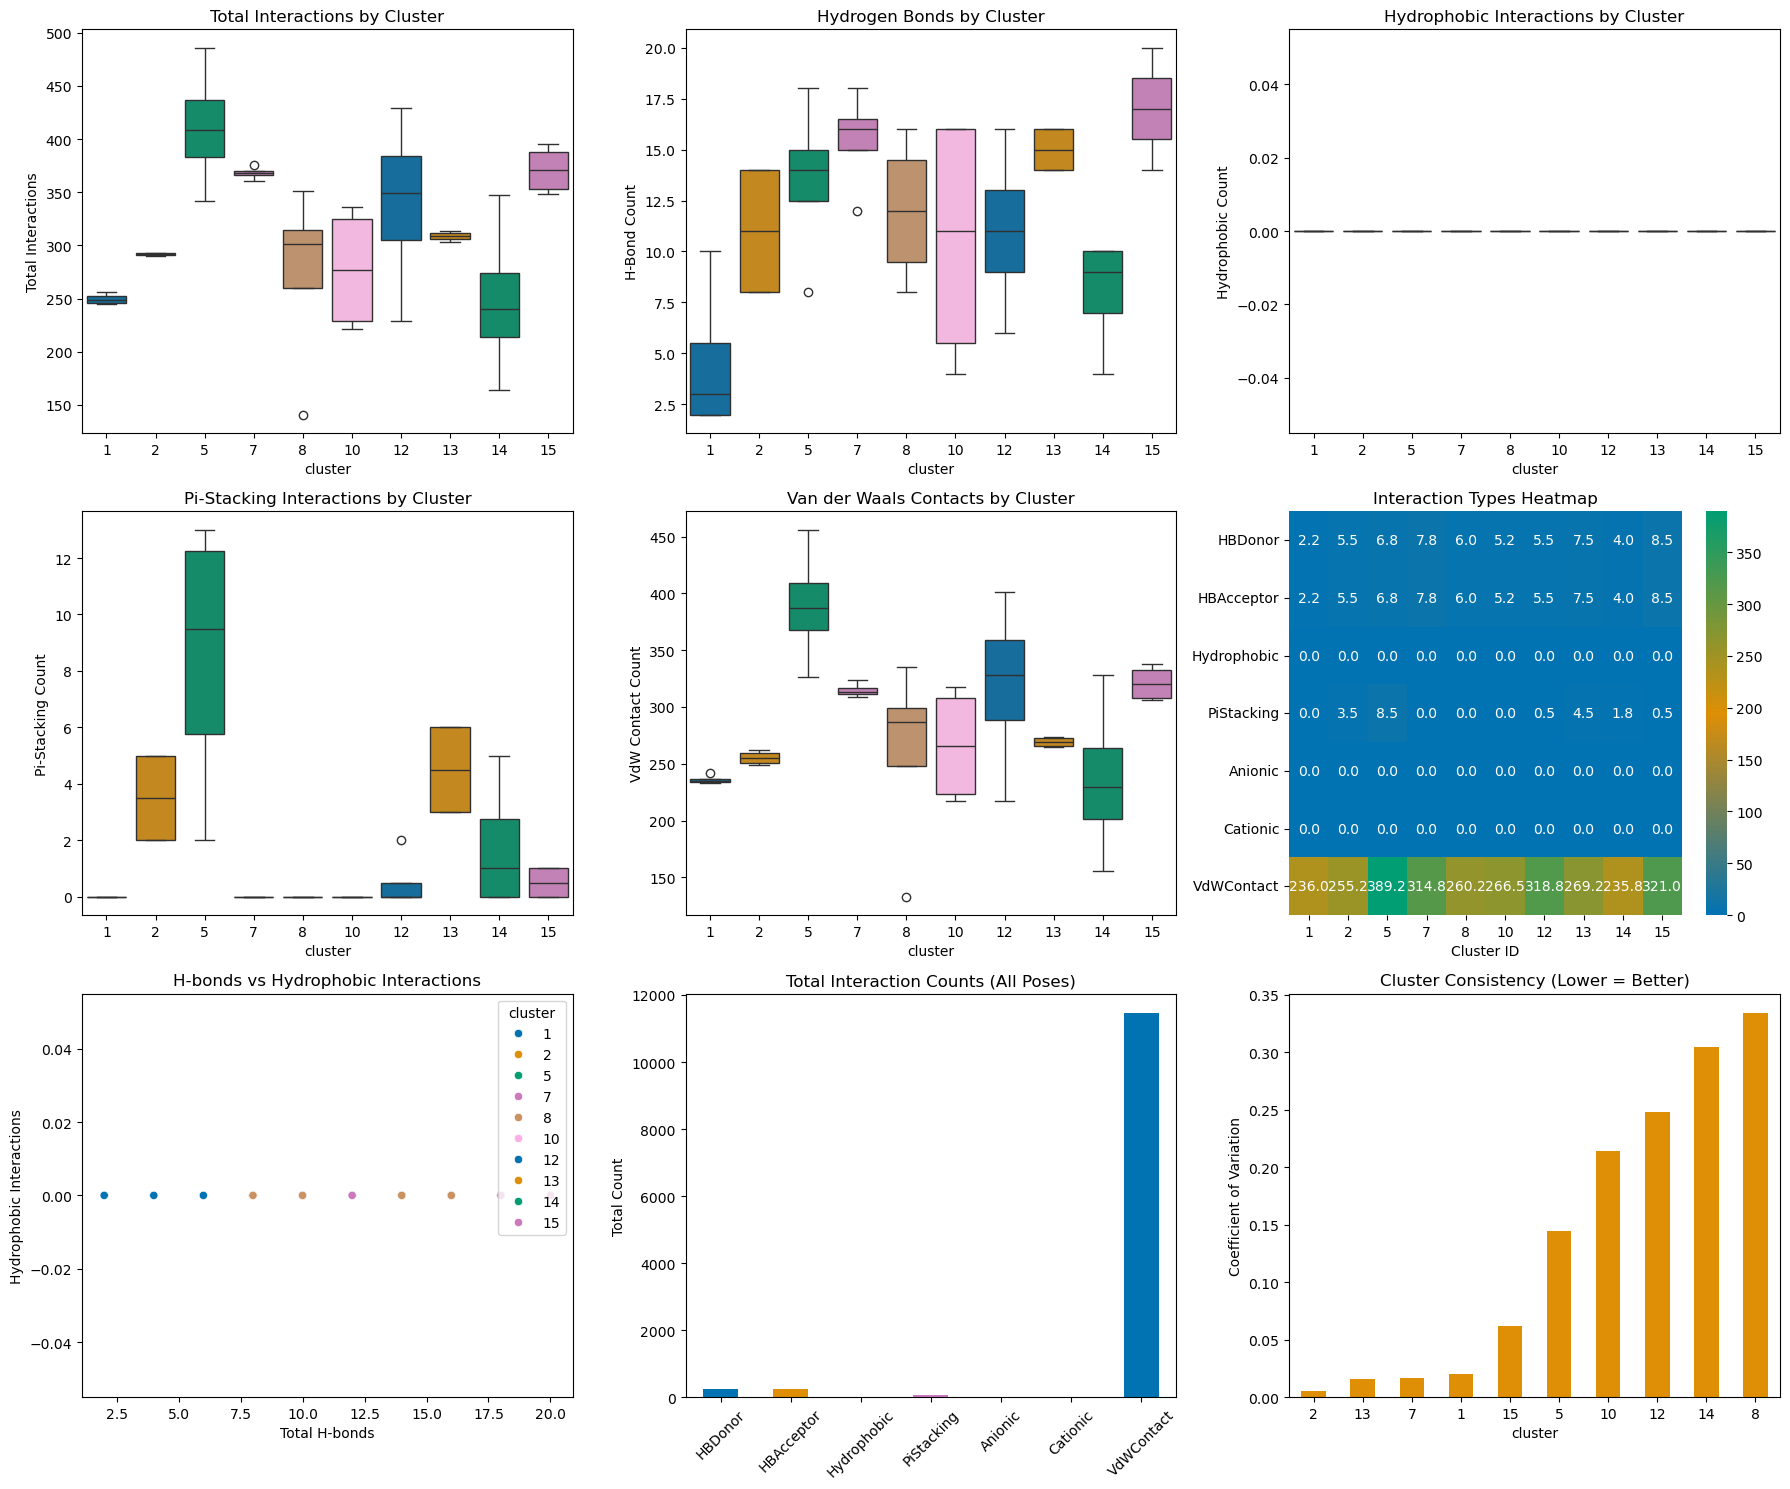


=== SUMMARY STATISTICS ===
        HBDonor       HBAcceptor       Hydrophobic      PiStacking        \
           mean   std       mean   std        mean  std       mean   std   
cluster                                                                    
1          2.25  1.89       2.25  1.89         0.0  0.0       0.00  0.00   
2          5.50  1.73       5.50  1.73         0.0  0.0       3.50  1.73   
5          6.75  2.06       6.75  2.06         0.0  0.0       8.50  5.07   
7          7.75  1.26       7.75  1.26         0.0  0.0       0.00  0.00   
8          6.00  1.83       6.00  1.83         0.0  0.0       0.00  0.00   
10         5.25  3.20       5.25  3.20         0.0  0.0       0.00  0.00   
12         5.50  2.08       5.50  2.08         0.0  0.0       0.50  1.00   
13         7.50  0.58       7.50  0.58         0.0  0.0       4.50  1.73   
14         4.00  1.41       4.00  1.41         0.0  0.0       1.75  2.36   
15         8.50  1.29       8.50  1.29         0.0  0.0     

In [12]:
# Complete modified version with professional color palettes
import datetime

# Define professional color palettes
professional_palettes = {
    'nature': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    'scientific': ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#FBAFE4'],
    'colorblind_friendly': ['#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628']
}

# Choose your palette here - change 'scientific' to 'nature' or 'colorblind_friendly' as desired
chosen_palette = professional_palettes['scientific']

if analysis_df is not None:
    print("Creating comprehensive visualizations with professional colors...")
    
    # Set up the plotting area
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    # Plot 1: Total interactions by cluster (box plot)
    sns.boxplot(data=analysis_df, x='cluster', y='total_interactions', ax=axes[0,0], 
                palette=chosen_palette)
    axes[0,0].set_title('Total Interactions by Cluster')
    axes[0,0].set_ylabel('Total Interactions')
    
    # Plot 2: Hydrogen bonds by cluster
    if 'HBDonor' in analysis_df.columns:
        analysis_df['total_hbonds'] = analysis_df['HBDonor'] + analysis_df['HBAcceptor']
        sns.boxplot(data=analysis_df, x='cluster', y='total_hbonds', ax=axes[0,1], 
                    palette=chosen_palette)
        axes[0,1].set_title('Hydrogen Bonds by Cluster')
        axes[0,1].set_ylabel('H-Bond Count')
    
    # Plot 3: Hydrophobic interactions by cluster
    if 'Hydrophobic' in analysis_df.columns:
        sns.boxplot(data=analysis_df, x='cluster', y='Hydrophobic', ax=axes[0,2], 
                    palette=chosen_palette)
        axes[0,2].set_title('Hydrophobic Interactions by Cluster')
        axes[0,2].set_ylabel('Hydrophobic Count')
    
    # Plot 4: Pi-stacking interactions
    if 'PiStacking' in analysis_df.columns:
        sns.boxplot(data=analysis_df, x='cluster', y='PiStacking', ax=axes[1,0], 
                    palette=chosen_palette)
        axes[1,0].set_title('Pi-Stacking Interactions by Cluster')
        axes[1,0].set_ylabel('Pi-Stacking Count')
    
    # Plot 5: Van der Waals contacts
    if 'VdWContact' in analysis_df.columns:
        sns.boxplot(data=analysis_df, x='cluster', y='VdWContact', ax=axes[1,1], 
                    palette=chosen_palette)
        axes[1,1].set_title('Van der Waals Contacts by Cluster')
        axes[1,1].set_ylabel('VdW Contact Count')
    
    # Plot 6: Cluster means heatmap - using scientific colormap
    interaction_cols = [col for col in ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 
                                       'Anionic', 'Cationic', 'VdWContact'] if col in analysis_df.columns]
    if interaction_cols:
        cluster_interaction_means = analysis_df.groupby('cluster')[interaction_cols].mean()
        # Create custom colormap from chosen palette
        from matplotlib.colors import LinearSegmentedColormap
        custom_cmap = LinearSegmentedColormap.from_list("custom", chosen_palette[:3])
        
        sns.heatmap(cluster_interaction_means.T, annot=True, fmt='.1f', 
                   cmap=custom_cmap, ax=axes[1,2])
        axes[1,2].set_title('Interaction Types Heatmap')
        axes[1,2].set_xlabel('Cluster ID')
    
    # Plot 7: Scatter plot - H-bonds vs Hydrophobic
    if 'total_hbonds' in analysis_df.columns and 'Hydrophobic' in analysis_df.columns:
        sns.scatterplot(data=analysis_df, x='total_hbonds', y='Hydrophobic', 
                       hue='cluster', ax=axes[2,0], palette=chosen_palette)
        axes[2,0].set_title('H-bonds vs Hydrophobic Interactions')
        axes[2,0].set_xlabel('Total H-bonds')
        axes[2,0].set_ylabel('Hydrophobic Interactions')
    
    # Plot 8: Interaction frequency across all poses - using first color from palette
    if interaction_cols:
        interaction_totals = analysis_df[interaction_cols].sum()
        # Create color list for each bar using the chosen palette
        bar_colors = [chosen_palette[i % len(chosen_palette)] for i in range(len(interaction_totals))]
        interaction_totals.plot(kind='bar', ax=axes[2,1], color=bar_colors)
        axes[2,1].set_title('Total Interaction Counts (All Poses)')
        axes[2,1].set_ylabel('Total Count')
        axes[2,1].tick_params(axis='x', rotation=45)
    
    # Plot 9: Cluster consistency (coefficient of variation) - using second color from palette
    if 'cluster_cv' in globals():
        cluster_cv['cv'].plot(kind='bar', ax=axes[2,2], color=chosen_palette[1])
        axes[2,2].set_title('Cluster Consistency (Lower = Better)')
        axes[2,2].set_ylabel('Coefficient of Variation')
        axes[2,2].tick_params(axis='x', rotation=0)
    
    # Save the figure BEFORE showing it
    plt.tight_layout()
    
    # Save with timestamp and palette name
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    palette_name = [k for k, v in professional_palettes.items() if v == chosen_palette][0]
    
    filename = f'interaction_analysis_{palette_name}_{timestamp}.png'
    pdf_filename = f'interaction_analysis_{palette_name}_{timestamp}.pdf'
    
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(pdf_filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"Plot saved as '{filename}' and '{pdf_filename}'")
    print(f"Using {palette_name} color palette")
    plt.show()
    
    # Summary statistics table
    print("\n=== SUMMARY STATISTICS ===")
    summary_stats = analysis_df[['cluster'] + interaction_cols + ['total_interactions']].groupby('cluster').agg(['mean', 'std']).round(2)
    print(summary_stats)
    
    # Best poses summary
    print(f"\n=== TOP 5 BEST POSES ===")
    best_poses = analysis_df.nlargest(5, 'total_interactions')
    for i, (idx, row) in enumerate(best_poses.iterrows()):
        print(f"{i+1}. {row['file']} (Cluster {row['cluster']})")
        print(f"   Total: {row['total_interactions']}, H-bonds: {row.get('total_hbonds', 'N/A')}, Hydrophobic: {row.get('Hydrophobic', 'N/A')}")

else:
    print("No data available for visualization")

# Quick palette switcher - uncomment the one you want to use:
# chosen_palette = professional_palettes['nature']          # Nature colors
# chosen_palette = professional_palettes['scientific']      # Scientific publication colors  
# chosen_palette = professional_palettes['colorblind_friendly']  # Colorblind-friendly colors

print("\nAvailable color palettes:")
for name, colors in professional_palettes.items():
    print(f"- {name}: {colors}")
print("\nTo change palette, modify 'chosen_palette' variable at the top of the code.")

In [13]:
# Interactive analysis and advanced visualizations
import sys
if analysis_df is not None and 'plotly' in sys.modules:
    print("Creating interactive visualizations...")
    
    # Interactive 3D scatter plot
    fig_3d = go.Figure(data=go.Scatter3d(
        x=analysis_df['total_interactions'],
        y=analysis_df.get('total_hbonds', analysis_df['HBDonor'] + analysis_df['HBAcceptor'] if 'HBDonor' in analysis_df.columns else analysis_df['total_interactions']*0.3),
        z=analysis_df.get('Hydrophobic', analysis_df['total_interactions']*0.2),
        mode='markers',
        marker=dict(
            size=8,
            color=analysis_df['cluster'],
            colorscale='viridis',
            colorbar=dict(title="Cluster ID"),
            showscale=True,
            line=dict(width=2, color='black')
        ),
        text=[f"File: {row['file']}<br>Cluster: {row['cluster']}<br>Total: {row['total_interactions']}<br>H-bonds: {row.get('total_hbonds', 'N/A')}<br>Hydrophobic: {row.get('Hydrophobic', 'N/A')}" 
              for _, row in analysis_df.iterrows()],
        hovertemplate='%{text}<extra></extra>'
    ))
    
    fig_3d.update_layout(
        title='3D Interaction Analysis<br>HADDOCK Protein-DNA Complexes',
        scene=dict(
            xaxis_title='Total Interactions',
            yaxis_title='Hydrogen Bonds',
            zaxis_title='Hydrophobic Interactions'
        ),
        width=800,
        height=600
    )
    
    fig_3d.show()
    
    # Interactive cluster comparison
    fig_box = go.Figure()
    
    for cluster in sorted(analysis_df['cluster'].unique()):
        cluster_data = analysis_df[analysis_df['cluster'] == cluster]['total_interactions']
        fig_box.add_trace(go.Box(
            y=cluster_data,
            name=f'Cluster {cluster}',
            boxpoints='all',
            jitter=0.3,
            pointpos=-1.8
        ))
    
    fig_box.update_layout(
        title='Interactive Cluster Comparison - Total Interactions',
        yaxis_title='Total Interactions',
        xaxis_title='Cluster',
        width=800,
        height=500
    )
    
    fig_box.show()
    
    # Interaction correlation heatmap
    interaction_cols = [col for col in ['HBDonor', 'HBAcceptor', 'Hydrophobic', 'PiStacking', 
                                       'Anionic', 'Cationic', 'VdWContact'] if col in analysis_df.columns]
    
    if len(interaction_cols) > 1:
        correlation_matrix = analysis_df[interaction_cols].corr()
        
        fig_corr = go.Figure(data=go.Heatmap(
            z=correlation_matrix.values,
            x=correlation_matrix.columns,
            y=correlation_matrix.columns,
            colorscale='RdBu',
            zmid=0,
            text=correlation_matrix.round(2).values,
            texttemplate="%{text}",
            textfont={"size": 12},
            hoverongaps=False
        ))
        
        fig_corr.update_layout(
            title='Interaction Type Correlation Matrix',
            width=600,
            height=600
        )
        
        fig_corr.show()

# Save comprehensive results
if analysis_df is not None:
    print("\nSaving comprehensive analysis results...")
    
    # Save main results
    analysis_df.to_csv("comprehensive_protein_dna_analysis.csv", index=False)
    print("Saved: comprehensive_protein_dna_analysis.csv")
    
    # Save cluster statistics
    if 'cluster_stats' in globals():
        cluster_stats.to_csv("cluster_interaction_statistics.csv")
        print("Saved: cluster_interaction_statistics.csv")
    
    # Save detailed residue interactions for top poses
    top_3_poses = analysis_df.nlargest(3, 'total_interactions')
    
    for _, row in top_3_poses.iterrows():
        if row['residue_interactions']:
            residue_df = pd.DataFrame(row['residue_interactions'])
            filename = f"residue_interactions_{row['file'].replace('.pdb', '')}.csv"
            residue_df.to_csv(filename, index=False)
            print(f"Saved: {filename}")
    
    print(f"\nAnalysis complete! Key findings:")
    print(f"- Best performing cluster: {analysis_df.groupby('cluster')['total_interactions'].mean().idxmax()}")
    print(f"- Average interactions per pose: {analysis_df['total_interactions'].mean():.1f}")
    print(f"- Most interactive pose: {analysis_df.loc[analysis_df['total_interactions'].idxmax(), 'file']}")
    
else:
    print("No analysis results to save")

Creating interactive visualizations...



Saving comprehensive analysis results...
Saved: comprehensive_protein_dna_analysis.csv
Saved: cluster_interaction_statistics.csv
Saved: residue_interactions_cluster5_1.csv
Saved: residue_interactions_cluster12_3.csv
Saved: residue_interactions_cluster5_3.csv

Analysis complete! Key findings:
- Best performing cluster: 5
- Average interactions per pose: 313.9
- Most interactive pose: cluster5_1.pdb


Creating ProLIF-style interaction fingerprint matrix with professional colors...
Working with: RNA
Found 87 unique protein residues
Found 50 unique RNA residues
Total unique interactions: 4350 possible pairs
Created fingerprint matrix: (40, 4350)
Interaction coverage: 1.5%

Top 10 most frequent protein-RNA interactions:
   1. GLN610-A56                    :  50.0% of poses
   2. GLN610-C57                    :  50.0% of poses
   3. GLN610-C43                    :  42.5% of poses
   4. ASP611-C43                    :  35.0% of poses
   5. GLN610-G44                    :  35.0% of poses
   6. ARG189-G53                    :  32.5% of poses
   7. THR577-C57                    :  32.5% of poses
   8. GLN610-C58                    :  30.0% of poses
   9. SER415-A40                    :  30.0% of poses
  10. ARG189-U55                    :  30.0% of poses

=== CLUSTER FINGERPRINT ANALYSIS ===

Cluster 1 top interactions:
  SER415-G41                    : 100.0%
  GLN303-G7                   

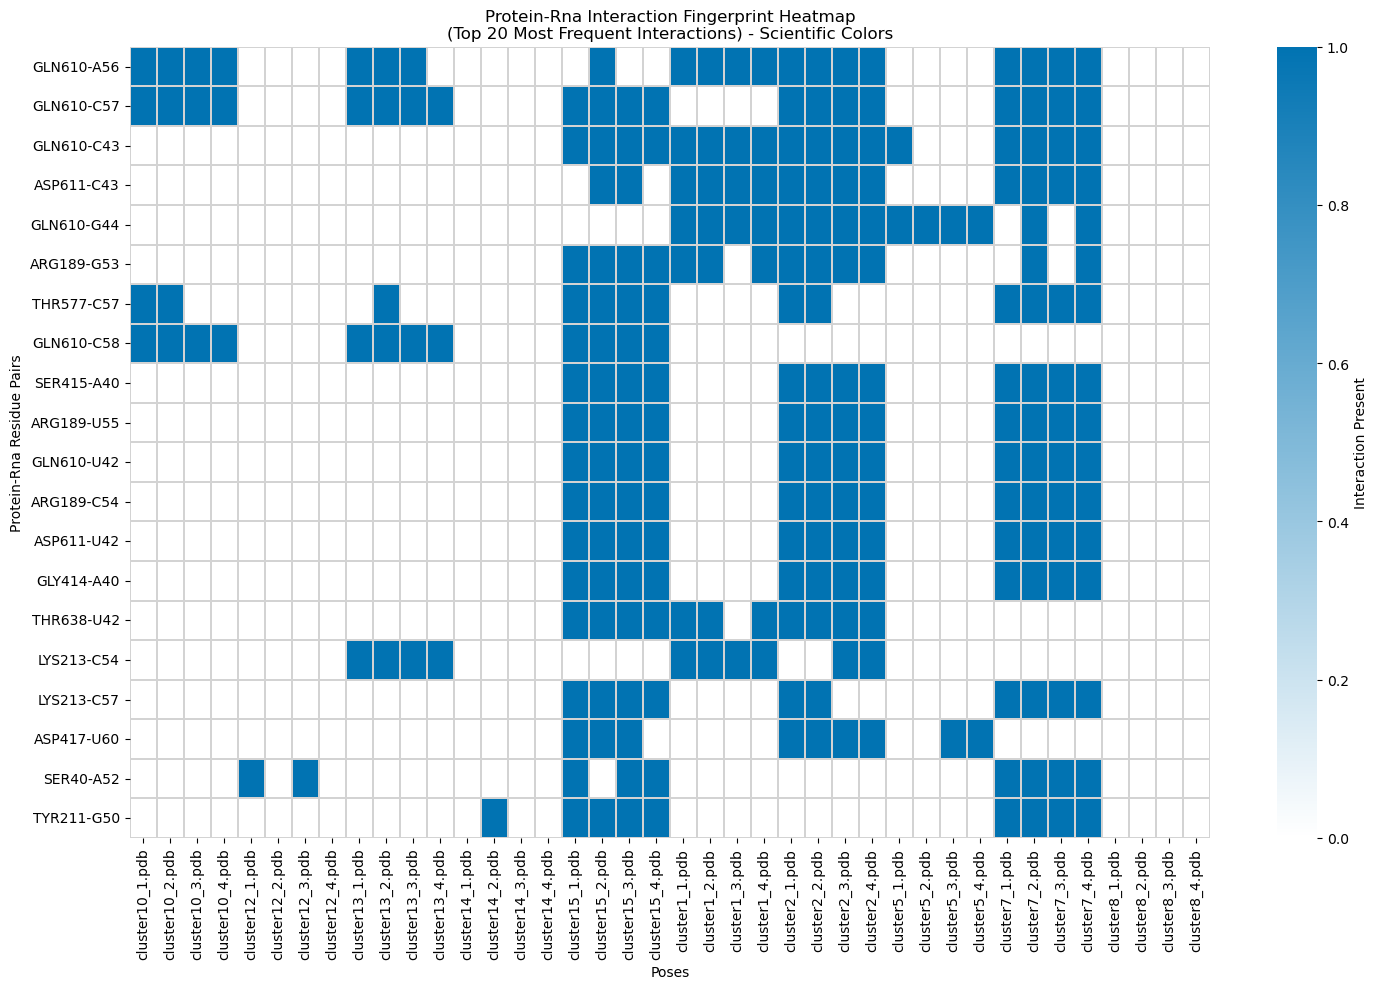


=== INTERACTION CONSERVATION ANALYSIS ===
Found 7 conserved interactions (>30% frequency):
  GLN610-A56                    :  50.0%
  GLN610-C57                    :  50.0%
  GLN610-C43                    :  42.5%
  ASP611-C43                    :  35.0%
  GLN610-G44                    :  35.0%
  ARG189-G53                    :  32.5%
  THR577-C57                    :  32.5%
Saved: conserved_interactions_rna_scientific_20251005_164934.csv
Saved: interaction_frequency_analysis_rna_scientific_20251005_164934.png and .pdf


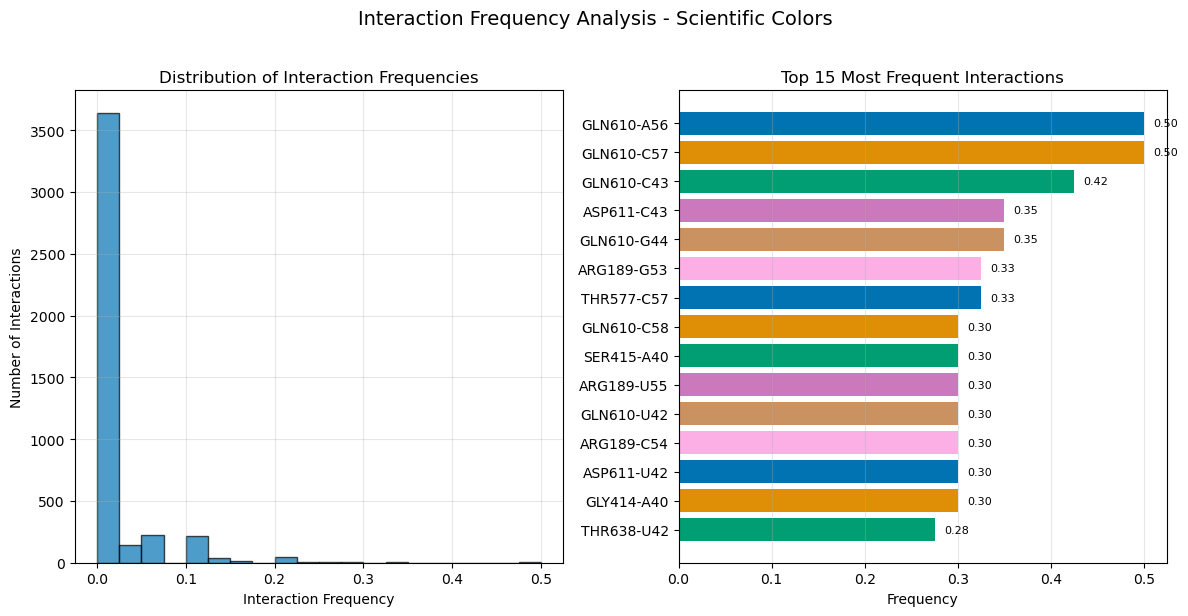

Saved: cluster_interaction_heatmap_rna_scientific_20251005_164934.png and .pdf


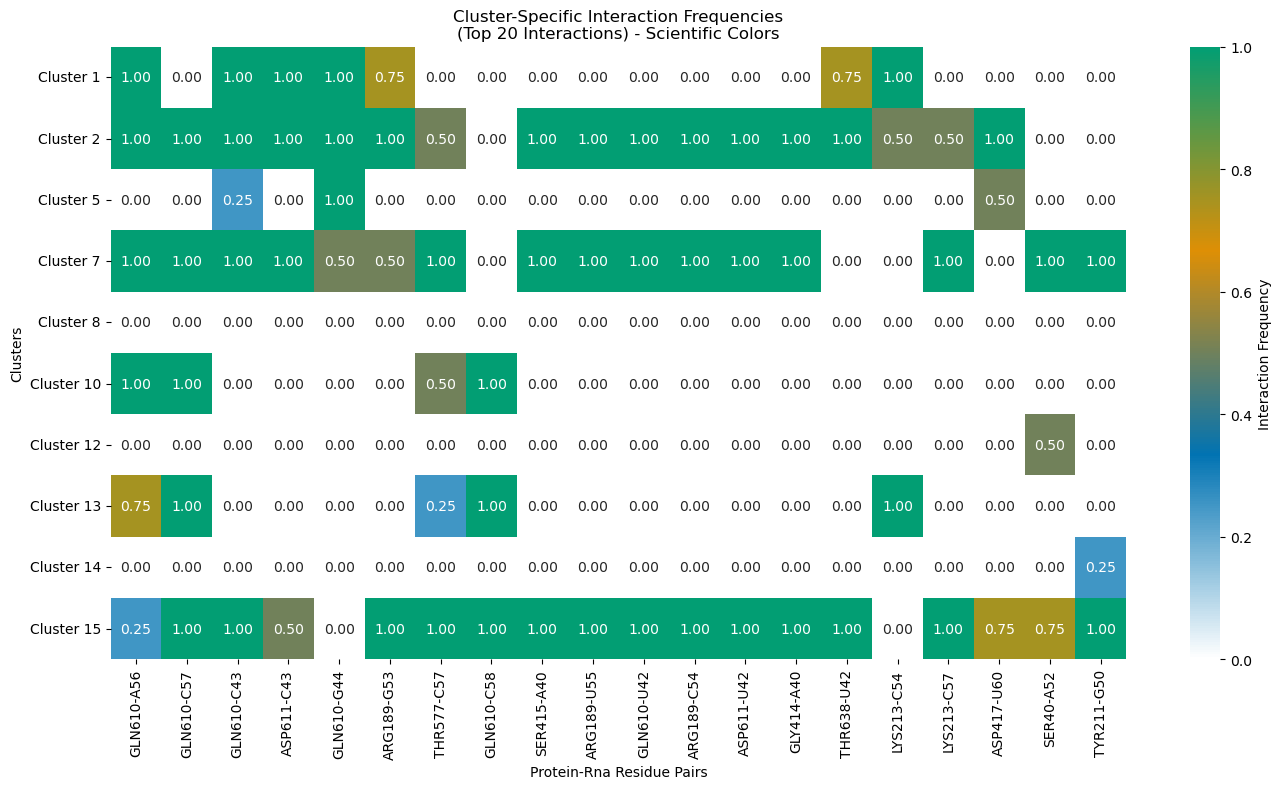

Saved: fingerprint_summary_stats_rna_scientific_20251005_164934.csv

=== SUMMARY ===
Total Poses: 40
Nucleic Acid Type: RNA
Total Possible Interactions: 4350
Average Interactions Per Pose: 63.725
Most Active Pose: cluster5_1.pdb
Highest Interaction Count: 96
Conservation Threshold 30Pct: 7
Total Unique Protein Residues: 87
Total Unique Rna Residues: 50
Color Palette Used: scientific

Using scientific color palette: ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#FBAFE4']

Available color palettes:
- nature: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
- scientific: ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#FBAFE4']
- colorblind_friendly: ['#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628']

To change palette, modify 'chosen_palette' variable at the top of the code.


In [14]:
# Create ProLIF-style interaction fingerprint matrix with professional colors
import datetime
from matplotlib.colors import LinearSegmentedColormap

# Define professional color palettes
professional_palettes = {
    'nature': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
    'scientific': ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#FBAFE4'],
    'colorblind_friendly': ['#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33', '#a65628']
}

# Choose your palette here - change 'scientific' to 'nature' or 'colorblind_friendly' as desired
chosen_palette = professional_palettes['scientific']

if analysis_df is not None:
    print("Creating ProLIF-style interaction fingerprint matrix with professional colors...")
    
    # Detect nucleic acid type(s)
    nucleic_types = analysis_df['nucleic_type'].unique() if 'nucleic_type' in analysis_df.columns else ['Unknown']
    nucleic_label = "nucleic acid"
    if len(nucleic_types) == 1:
        if nucleic_types[0] == 'DNA':
            nucleic_label = "DNA"
        elif nucleic_types[0] == 'RNA':
            nucleic_label = "RNA"
    print(f"Working with: {', '.join(nucleic_types)}")
    
    # Collect all unique protein-nucleic acid residue pairs across all poses
    all_protein_residues = set()
    all_nucleic_residues = set()
    all_interactions_dict = {}
    
    for _, row in analysis_df.iterrows():
        pose_name = row['file']
        if row['residue_interactions']:
            for interaction in row['residue_interactions']:
                prot_res = interaction['protein_residue']
                nucleic_res = interaction['nucleic_residue']
                all_protein_residues.add(prot_res)
                all_nucleic_residues.add(nucleic_res)
                
                # Store interaction for this pose
                pair = (prot_res, nucleic_res)
                if pose_name not in all_interactions_dict:
                    all_interactions_dict[pose_name] = set()
                all_interactions_dict[pose_name].add(pair)
    
    print(f"Found {len(all_protein_residues)} unique protein residues")
    print(f"Found {len(all_nucleic_residues)} unique {nucleic_label} residues")
    print(f"Total unique interactions: {len(all_protein_residues) * len(all_nucleic_residues)} possible pairs")
    
    # Create interaction matrix (similar to ProLIF fingerprint)
    interaction_pairs = []
    for prot_res in sorted(all_protein_residues):
        for nucleic_res in sorted(all_nucleic_residues):
            interaction_pairs.append((prot_res, nucleic_res))
    
    # Create binary fingerprint matrix
    fingerprint_data = []
    pose_names = []
    
    for _, row in analysis_df.iterrows():
        pose_name = row['file']
        pose_names.append(pose_name)
        
        # Create binary vector for this pose
        pose_vector = []
        pose_interactions = all_interactions_dict.get(pose_name, set())
        
        for pair in interaction_pairs:
            if pair in pose_interactions:
                pose_vector.append(1)
            else:
                pose_vector.append(0)
        
        fingerprint_data.append(pose_vector)
    
    # Create fingerprint DataFrame
    fingerprint_df = pd.DataFrame(
        fingerprint_data, 
        index=pose_names,
        columns=[f"{pair[0]}-{pair[1]}" for pair in interaction_pairs]
    )
    
    print(f"Created fingerprint matrix: {fingerprint_df.shape}")
    print(f"Interaction coverage: {(fingerprint_df.sum().sum() / fingerprint_df.size * 100):.1f}%")
    
    # Most frequent interactions
    interaction_frequencies = fingerprint_df.mean().sort_values(ascending=False)
    print(f"\nTop 10 most frequent protein-{nucleic_label} interactions:")
    for i, (interaction, freq) in enumerate(interaction_frequencies.head(10).items()):
        print(f"  {i+1:2d}. {interaction:30s}: {freq*100:5.1f}% of poses")
    
    # Cluster-based fingerprint analysis
    print(f"\n=== CLUSTER FINGERPRINT ANALYSIS ===")
    
    # Add cluster info to fingerprint
    cluster_info = []
    for pose_name in fingerprint_df.index:
        cluster = analysis_df[analysis_df['file'] == pose_name]['cluster'].iloc[0]
        cluster_info.append(cluster)
    
    fingerprint_df['cluster'] = cluster_info
    
    # Calculate cluster-specific interaction frequencies
    cluster_summary = {}  # Store for later export
    for cluster in sorted(analysis_df['cluster'].unique()):
        cluster_data = fingerprint_df[fingerprint_df['cluster'] == cluster]
        cluster_interactions = cluster_data.drop('cluster', axis=1).mean().sort_values(ascending=False).head(5)
        cluster_summary[f'Cluster_{cluster}'] = cluster_interactions
        
        print(f"\nCluster {cluster} top interactions:")
        for interaction, freq in cluster_interactions.items():
            print(f"  {interaction:30s}: {freq*100:5.1f}%")
    
    # Get palette name for file naming
    palette_name = [k for k, v in professional_palettes.items() if v == chosen_palette][0]
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Determine file naming based on nucleic acid type
    nucleic_file_label = nucleic_types[0].lower().replace('/', '_') if len(nucleic_types) == 1 else 'nucleic'
    
    # Save cluster summary to CSV
    cluster_summary_df = pd.DataFrame(cluster_summary)
    cluster_summary_df.to_csv(f"cluster_interaction_summary_{nucleic_file_label}_{palette_name}_{timestamp}.csv")
    print(f"\nSaved: cluster_interaction_summary_{nucleic_file_label}_{palette_name}_{timestamp}.csv")
    
    # Save fingerprint matrix
    fingerprint_df.to_csv(f"protein_{nucleic_file_label}_fingerprint_matrix_{palette_name}_{timestamp}.csv")
    print(f"Saved: protein_{nucleic_file_label}_fingerprint_matrix_{palette_name}_{timestamp}.csv")
    
    # Create custom colormap from chosen palette
    # Use first two colors for binary heatmap (white to main color)
    heatmap_colors = ['white', chosen_palette[0]]
    custom_heatmap_cmap = LinearSegmentedColormap.from_list("custom_binary", heatmap_colors)
    
    # Create fingerprint heatmap for top interactions with professional colors
    top_interactions = interaction_frequencies.head(20).index
    heatmap_data = fingerprint_df[top_interactions]
    
    plt.figure(figsize=(15, 10))
    sns.heatmap(heatmap_data.T, cmap=custom_heatmap_cmap, 
                cbar_kws={'label': 'Interaction Present'},
                linewidths=0.1, linecolor='lightgray')
    plt.title(f'Protein-{nucleic_label.title()} Interaction Fingerprint Heatmap\n(Top 20 Most Frequent Interactions) - {palette_name.title()} Colors')
    plt.xlabel('Poses')
    plt.ylabel(f'Protein-{nucleic_label.title()} Residue Pairs')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # SAVE THE HEATMAP with palette info
    heatmap_filename = f'protein_{nucleic_file_label}_fingerprint_heatmap_{palette_name}_{timestamp}'
    plt.savefig(f'{heatmap_filename}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{heatmap_filename}.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {heatmap_filename}.png and .pdf")
    plt.show()
    
    # Conservation analysis
    print(f"\n=== INTERACTION CONSERVATION ANALYSIS ===")
    conserved_interactions = interaction_frequencies[interaction_frequencies > 0.3]  # >30% conservation
    
    print(f"Found {len(conserved_interactions)} conserved interactions (>30% frequency):")
    for interaction, freq in conserved_interactions.items():
        print(f"  {interaction:30s}: {freq*100:5.1f}%")
    
    # Save conservation analysis
    conserved_df = pd.DataFrame({
        'Interaction': conserved_interactions.index,
        'Frequency': conserved_interactions.values,
        'Percentage': conserved_interactions.values * 100
    })
    conserved_df.to_csv(f"conserved_interactions_{nucleic_file_label}_{palette_name}_{timestamp}.csv", index=False)
    print(f"Saved: conserved_interactions_{nucleic_file_label}_{palette_name}_{timestamp}.csv")
    
    # Create additional visualization with professional colors
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot 1: Interaction frequency distribution
    interaction_frequencies.hist(bins=20, edgecolor='black', color=chosen_palette[0], alpha=0.7, ax=ax1)
    ax1.set_xlabel('Interaction Frequency')
    ax1.set_ylabel('Number of Interactions')
    ax1.set_title('Distribution of Interaction Frequencies')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Top 15 most frequent interactions with rotating colors
    top_15_interactions = interaction_frequencies.head(15)
    bar_colors = [chosen_palette[i % len(chosen_palette)] for i in range(len(top_15_interactions))]
    
    bars = ax2.barh(range(len(top_15_interactions)), top_15_interactions.values, color=bar_colors)
    ax2.set_yticks(range(len(top_15_interactions)))
    ax2.set_yticklabels(top_15_interactions.index)
    ax2.set_xlabel('Frequency')
    ax2.set_title('Top 15 Most Frequent Interactions')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, top_15_interactions.values)):
        ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.2f}', 
                va='center', fontsize=8, color='black')
    
    plt.suptitle(f'Interaction Frequency Analysis - {palette_name.title()} Colors', fontsize=14, y=1.02)
    plt.tight_layout()
    
    freq_filename = f'interaction_frequency_analysis_{nucleic_file_label}_{palette_name}_{timestamp}'
    plt.savefig(f'{freq_filename}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{freq_filename}.pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {freq_filename}.png and .pdf")
    plt.show()
    
    # Create cluster-specific heatmap
    if len(analysis_df['cluster'].unique()) > 1:
        plt.figure(figsize=(14, 8))
        
        # Create cluster frequency matrix for top interactions
        cluster_freq_matrix = []
        cluster_labels = []
        
        for cluster in sorted(analysis_df['cluster'].unique()):
            cluster_data = fingerprint_df[fingerprint_df['cluster'] == cluster]
            cluster_freqs = cluster_data[top_interactions].mean()
            cluster_freq_matrix.append(cluster_freqs.values)
            cluster_labels.append(f'Cluster {cluster}')
        
        cluster_freq_df = pd.DataFrame(cluster_freq_matrix, 
                                      index=cluster_labels, 
                                      columns=top_interactions)
        
        # Use chosen palette for this heatmap
        cluster_cmap = LinearSegmentedColormap.from_list("cluster_cmap", 
                                                        ['white'] + chosen_palette[:3])
        
        sns.heatmap(cluster_freq_df, annot=True, fmt='.2f', cmap=cluster_cmap,
                   cbar_kws={'label': 'Interaction Frequency'})
        plt.title(f'Cluster-Specific Interaction Frequencies\n(Top 20 Interactions) - {palette_name.title()} Colors')
        plt.xlabel(f'Protein-{nucleic_label.title()} Residue Pairs')
        plt.ylabel('Clusters')
        plt.xticks(rotation=90)
        plt.tight_layout()
        
        cluster_heatmap_filename = f'cluster_interaction_heatmap_{nucleic_file_label}_{palette_name}_{timestamp}'
        plt.savefig(f'{cluster_heatmap_filename}.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f'{cluster_heatmap_filename}.pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {cluster_heatmap_filename}.png and .pdf")
        plt.show()
    
    # Summary statistics
    summary_stats = {
        'Total_poses': len(fingerprint_df),
        'Nucleic_acid_type': ', '.join(nucleic_types),
        'Total_possible_interactions': len(interaction_pairs),
        'Average_interactions_per_pose': fingerprint_df.drop('cluster', axis=1).sum(axis=1).mean(),
        'Most_active_pose': fingerprint_df.drop('cluster', axis=1).sum(axis=1).idxmax(),
        'Highest_interaction_count': fingerprint_df.drop('cluster', axis=1).sum(axis=1).max(),
        'Conservation_threshold_30pct': len(conserved_interactions),
        'Total_unique_protein_residues': len(all_protein_residues),
        f'Total_unique_{nucleic_label}_residues': len(all_nucleic_residues),
        'Color_palette_used': palette_name
    }
    
    # Save summary statistics
    summary_filename = f"fingerprint_summary_stats_{nucleic_file_label}_{palette_name}_{timestamp}.csv"
    pd.Series(summary_stats).to_csv(summary_filename, header=['Value'])
    print(f"Saved: {summary_filename}")
    
    print(f"\n=== SUMMARY ===")
    for key, value in summary_stats.items():
        print(f"{key.replace('_', ' ').title()}: {value}")
    
    print(f"\nUsing {palette_name} color palette: {chosen_palette}")

else:
    print("No analysis data available for fingerprint creation")

# Quick palette switcher - uncomment the one you want to use:
# chosen_palette = professional_palettes['nature']          # Nature colors
# chosen_palette = professional_palettes['scientific']      # Scientific publication colors  
# chosen_palette = professional_palettes['colorblind_friendly']  # Colorblind-friendly colors

print("\nAvailable color palettes:")
for name, colors in professional_palettes.items():
    print(f"- {name}: {colors}")
print("\nTo change palette, modify 'chosen_palette' variable at the top of the code.")

Performing similarity analysis between poses...
Calculated similarity matrix: (40, 40)
Mean similarity: 0.081
Std similarity: 0.191


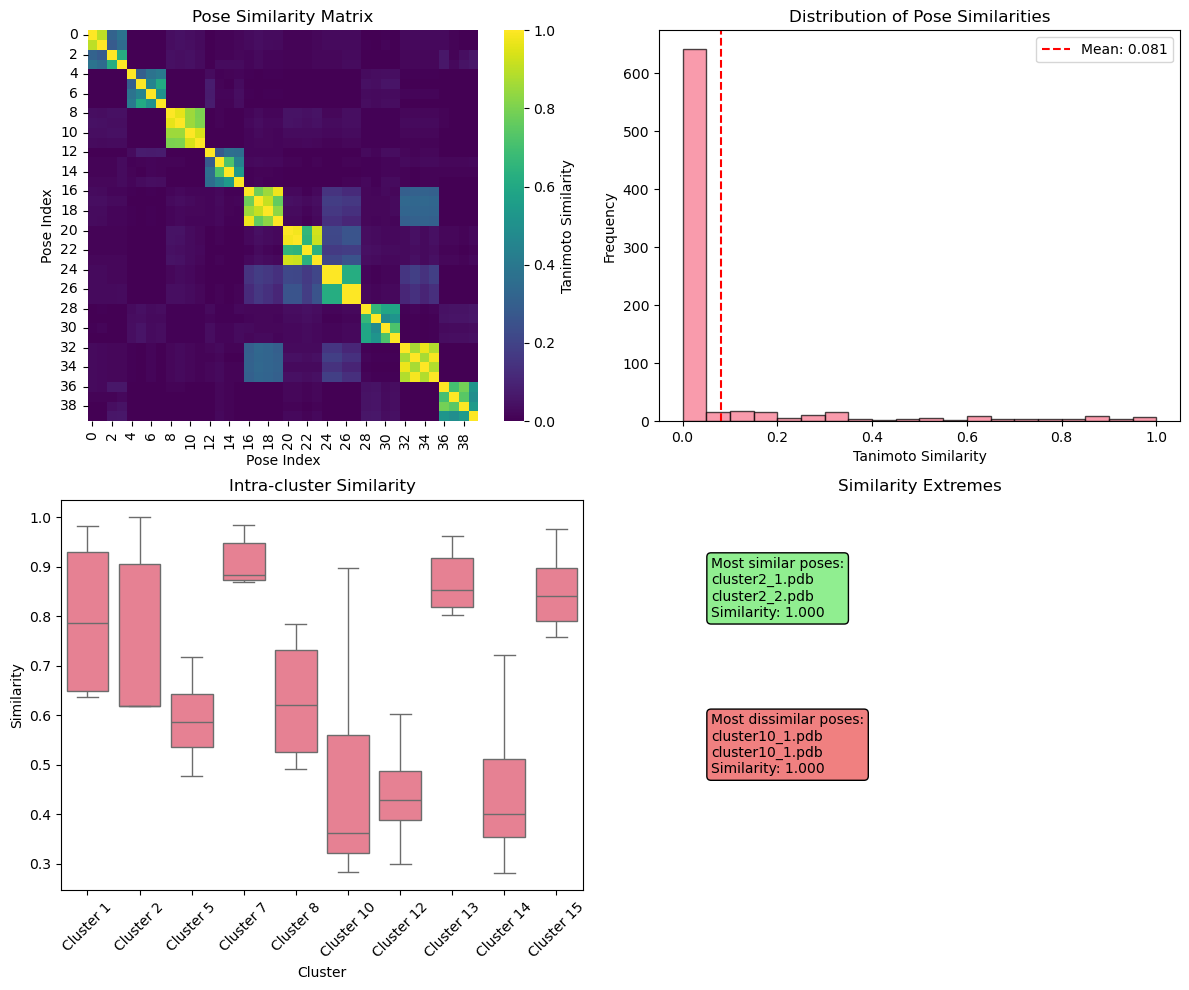


=== CLUSTER SIMILARITY ANALYSIS ===
Cluster 1: Mean intra-similarity = 0.796 ± 0.150
Cluster 2: Mean intra-similarity = 0.746 ± 0.179
Cluster 5: Mean intra-similarity = 0.592 ± 0.080
Cluster 7: Mean intra-similarity = 0.910 ± 0.048
Cluster 8: Mean intra-similarity = 0.630 ± 0.116
Cluster 10: Mean intra-similarity = 0.474 ± 0.219
Cluster 12: Mean intra-similarity = 0.441 ± 0.095
Cluster 13: Mean intra-similarity = 0.870 ± 0.061
Cluster 14: Mean intra-similarity = 0.449 ± 0.145
Cluster 15: Mean intra-similarity = 0.852 ± 0.075

Saved: pose_similarity_matrix.csv


In [15]:
# Similarity analysis between poses using fingerprint data
if 'fingerprint_df' in locals() and fingerprint_df is not None:
    print("Performing similarity analysis between poses...")
    
    # Calculate Tanimoto similarity matrix
    from scipy.spatial.distance import pdist, squareform
    from scipy.stats import pearsonr
    
    # Remove cluster column for similarity calculation
    fingerprint_matrix = fingerprint_df.drop('cluster', axis=1).values
    
    def tanimoto_similarity(vec1, vec2):
        """Calculate Tanimoto similarity between two binary vectors."""
        intersection = np.sum(vec1 & vec2)
        union = np.sum(vec1 | vec2)
        return intersection / union if union > 0 else 0
    
    # Calculate pairwise Tanimoto similarities
    n_poses = len(fingerprint_matrix)
    similarity_matrix = np.zeros((n_poses, n_poses))
    
    for i in range(n_poses):
        for j in range(i, n_poses):
            if i == j:
                similarity_matrix[i, j] = 1.0
            else:
                sim = tanimoto_similarity(fingerprint_matrix[i], fingerprint_matrix[j])
                similarity_matrix[i, j] = sim
                similarity_matrix[j, i] = sim
    
    print(f"Calculated similarity matrix: {similarity_matrix.shape}")
    print(f"Mean similarity: {np.mean(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]):.3f}")
    print(f"Std similarity: {np.std(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]):.3f}")
    
    # Visualize similarity matrix
    plt.figure(figsize=(12, 10))
    
    # Create similarity heatmap
    plt.subplot(2, 2, 1)
    sns.heatmap(similarity_matrix, cmap='viridis', square=True, cbar_kws={'label': 'Tanimoto Similarity'})
    plt.title('Pose Similarity Matrix')
    plt.xlabel('Pose Index')
    plt.ylabel('Pose Index')
    
    # Similarity distribution
    plt.subplot(2, 2, 2)
    upper_triangle = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    plt.hist(upper_triangle, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(np.mean(upper_triangle), color='red', linestyle='--', 
                label=f'Mean: {np.mean(upper_triangle):.3f}')
    plt.xlabel('Tanimoto Similarity')
    plt.ylabel('Frequency')
    plt.title('Distribution of Pose Similarities')
    plt.legend()
    
    # Cluster-based similarity analysis
    plt.subplot(2, 2, 3)
    cluster_similarities = []
    cluster_labels = []
    
    for cluster in sorted(analysis_df['cluster'].unique()):
        cluster_indices = [i for i, row in enumerate(fingerprint_df.iterrows()) 
                          if row[1]['cluster'] == cluster]
        
        if len(cluster_indices) > 1:
            cluster_sim_values = []
            for i in range(len(cluster_indices)):
                for j in range(i+1, len(cluster_indices)):
                    idx1, idx2 = cluster_indices[i], cluster_indices[j]
                    cluster_sim_values.append(similarity_matrix[idx1, idx2])
            
            if cluster_sim_values:
                cluster_similarities.extend(cluster_sim_values)
                cluster_labels.extend([f'Cluster {cluster}'] * len(cluster_sim_values))
    
    if cluster_similarities:
        cluster_sim_df = pd.DataFrame({
            'Similarity': cluster_similarities,
            'Cluster': cluster_labels
        })
        sns.boxplot(data=cluster_sim_df, x='Cluster', y='Similarity')
        plt.title('Intra-cluster Similarity')
        plt.xticks(rotation=45)
    
    # Most similar and dissimilar poses
    plt.subplot(2, 2, 4)
    
    # Find most similar pair (excluding diagonal)
    mask = np.triu(np.ones_like(similarity_matrix, dtype=bool), k=1)
    max_sim_idx = np.unravel_index(np.argmax(similarity_matrix * mask), similarity_matrix.shape)
    min_sim_idx = np.unravel_index(np.argmin(similarity_matrix * mask), similarity_matrix.shape)
    
    pose_names = list(fingerprint_df.index)
    
    similarity_stats = [
        f"Most similar poses:\n{pose_names[max_sim_idx[0]]}\n{pose_names[max_sim_idx[1]]}\nSimilarity: {similarity_matrix[max_sim_idx]:.3f}",
        f"Most dissimilar poses:\n{pose_names[min_sim_idx[0]]}\n{pose_names[min_sim_idx[1]]}\nSimilarity: {similarity_matrix[min_sim_idx]:.3f}"
    ]
    
    plt.text(0.1, 0.7, similarity_stats[0], transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
    plt.text(0.1, 0.3, similarity_stats[1], transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    plt.axis('off')
    plt.title('Similarity Extremes')
    
    plt.tight_layout()
    plt.show()
    
    # Cluster similarity summary
    print(f"\n=== CLUSTER SIMILARITY ANALYSIS ===")
    
    for cluster in sorted(analysis_df['cluster'].unique()):
        cluster_poses = fingerprint_df[fingerprint_df['cluster'] == cluster]
        if len(cluster_poses) > 1:
            cluster_indices = [fingerprint_df.index.get_loc(idx) for idx in cluster_poses.index]
            
            # Calculate intra-cluster similarities
            intra_similarities = []
            for i in range(len(cluster_indices)):
                for j in range(i+1, len(cluster_indices)):
                    idx1, idx2 = cluster_indices[i], cluster_indices[j]
                    intra_similarities.append(similarity_matrix[idx1, idx2])
            
            if intra_similarities:
                print(f"Cluster {cluster}: Mean intra-similarity = {np.mean(intra_similarities):.3f} ± {np.std(intra_similarities):.3f}")

    # Save similarity matrix
    similarity_df = pd.DataFrame(similarity_matrix, 
                                index=fingerprint_df.index, 
                                columns=fingerprint_df.index)
    similarity_df.to_csv("pose_similarity_matrix.csv")
    print(f"\nSaved: pose_similarity_matrix.csv")
    
else:
    print("No fingerprint data available for similarity analysis")

Creating publication-quality interaction diagrams...
Works with both DNA and RNA structures
Creating publication diagram 1/3: cluster5_1.pdb (RNA)
Saved: publication_diagram_cluster5_1.png and publication_diagram_cluster5_1.pdf


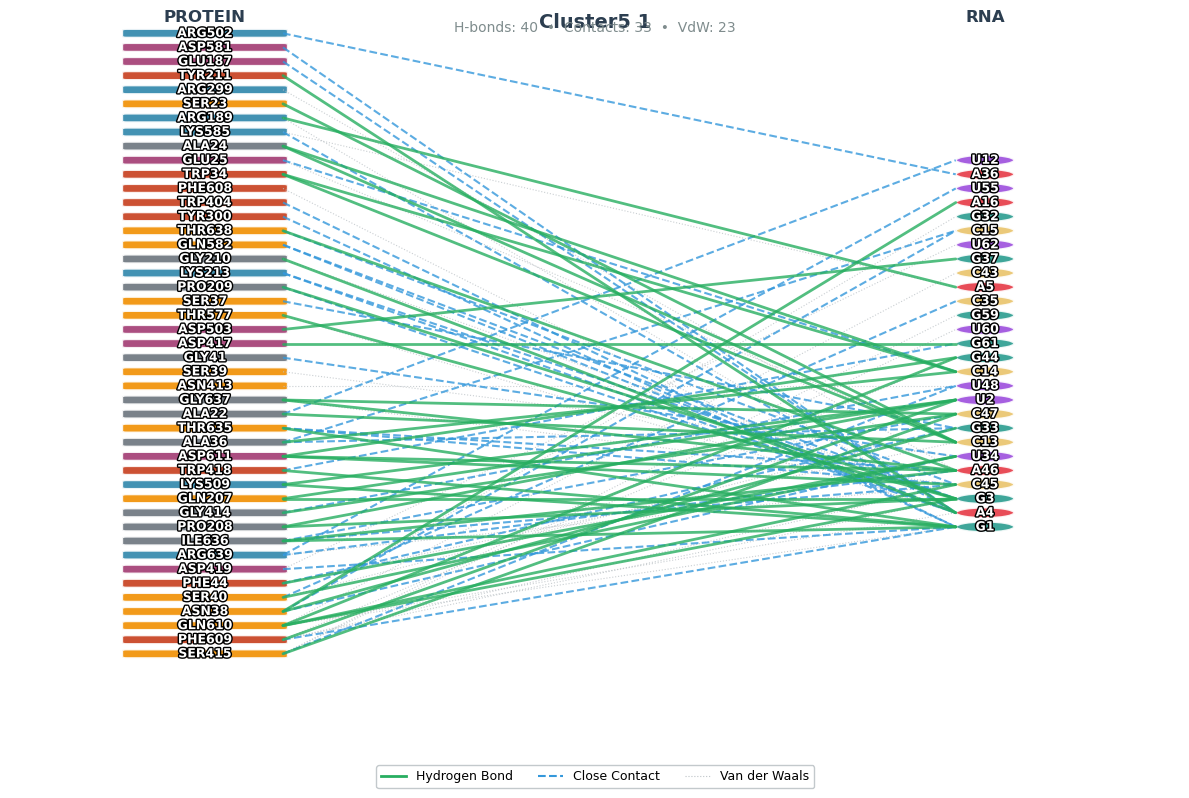

Creating publication diagram 2/3: cluster12_3.pdb (RNA)
Saved: publication_diagram_cluster12_3.png and publication_diagram_cluster12_3.pdf


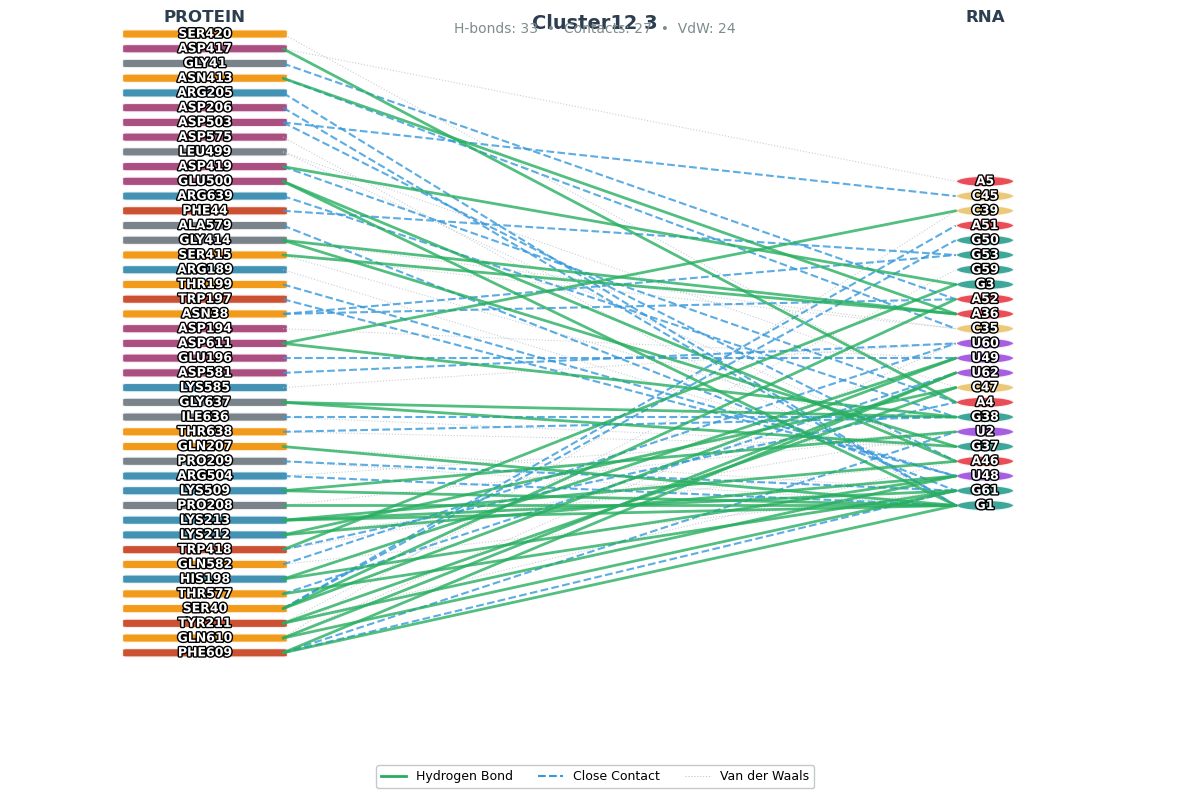

Creating publication diagram 3/3: cluster5_3.pdb (RNA)
Saved: publication_diagram_cluster5_3.png and publication_diagram_cluster5_3.pdf


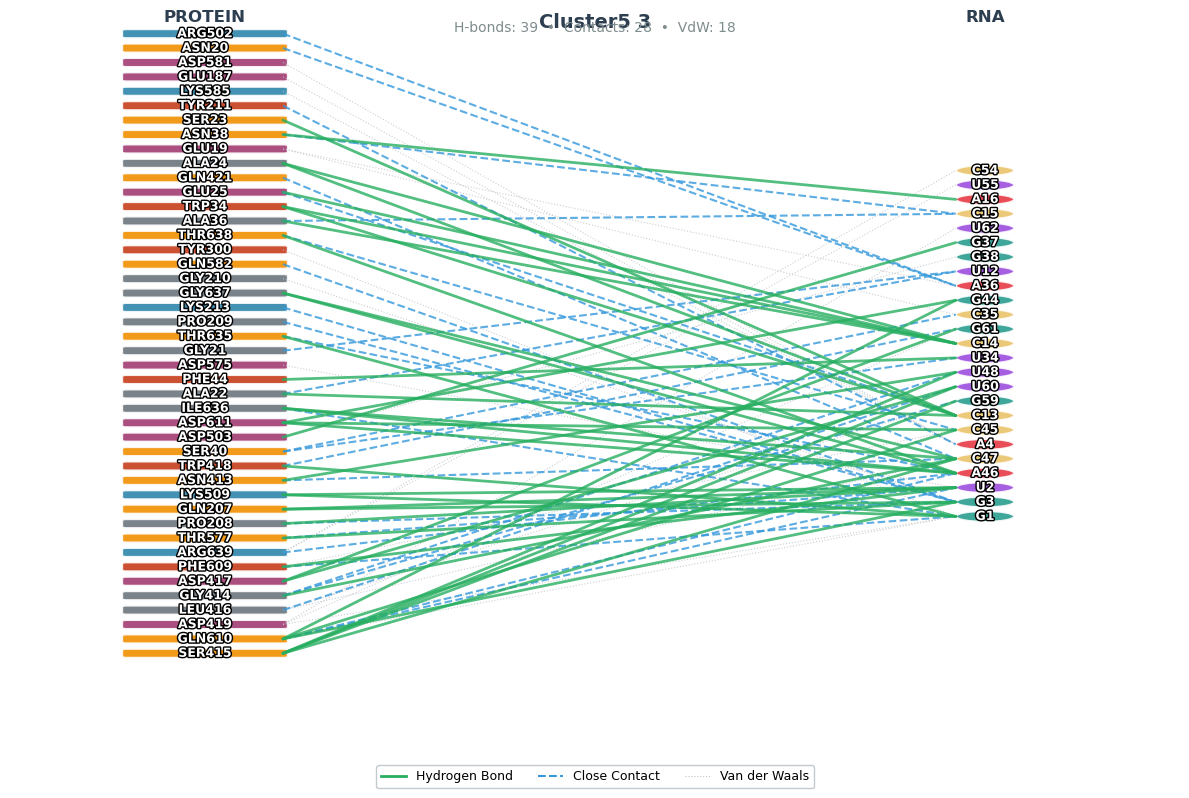


Creating consistent diagrams (H-bonds only)...
Saved: publication_diagram_hbonds_cluster5_1.png


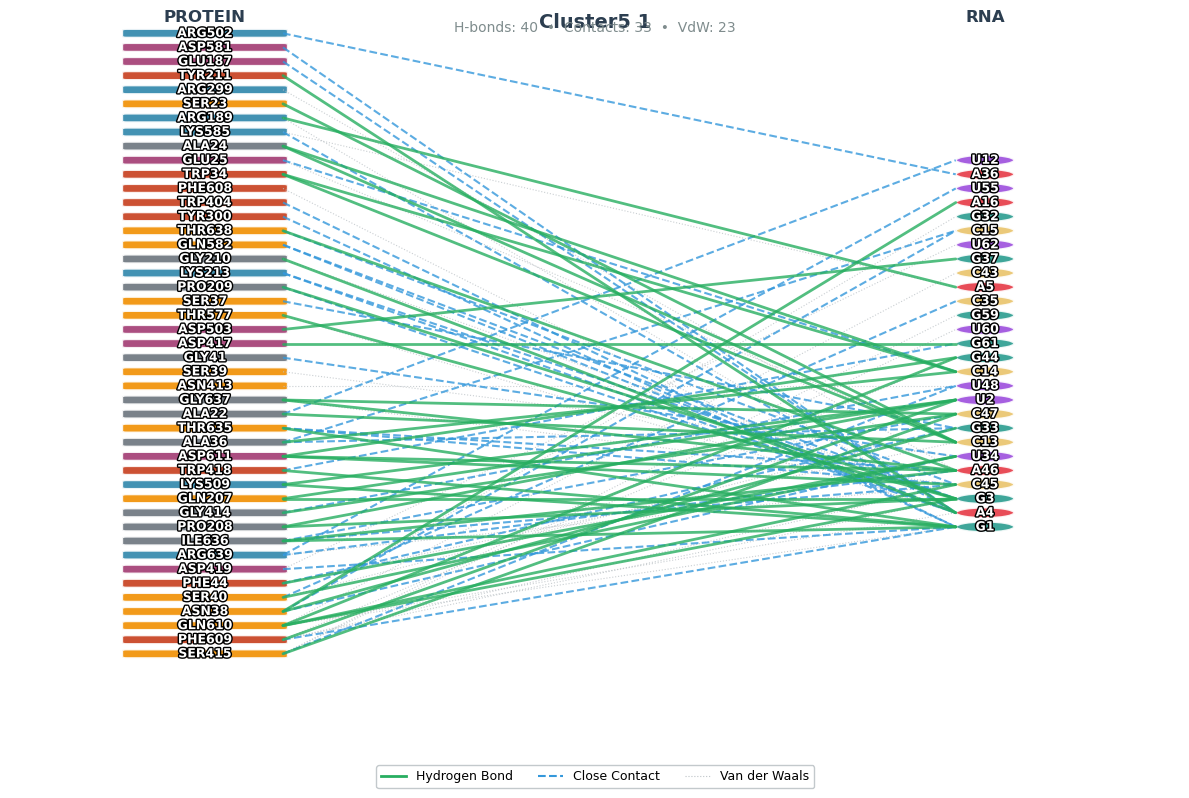

Saved: publication_diagram_hbonds_cluster12_3.png


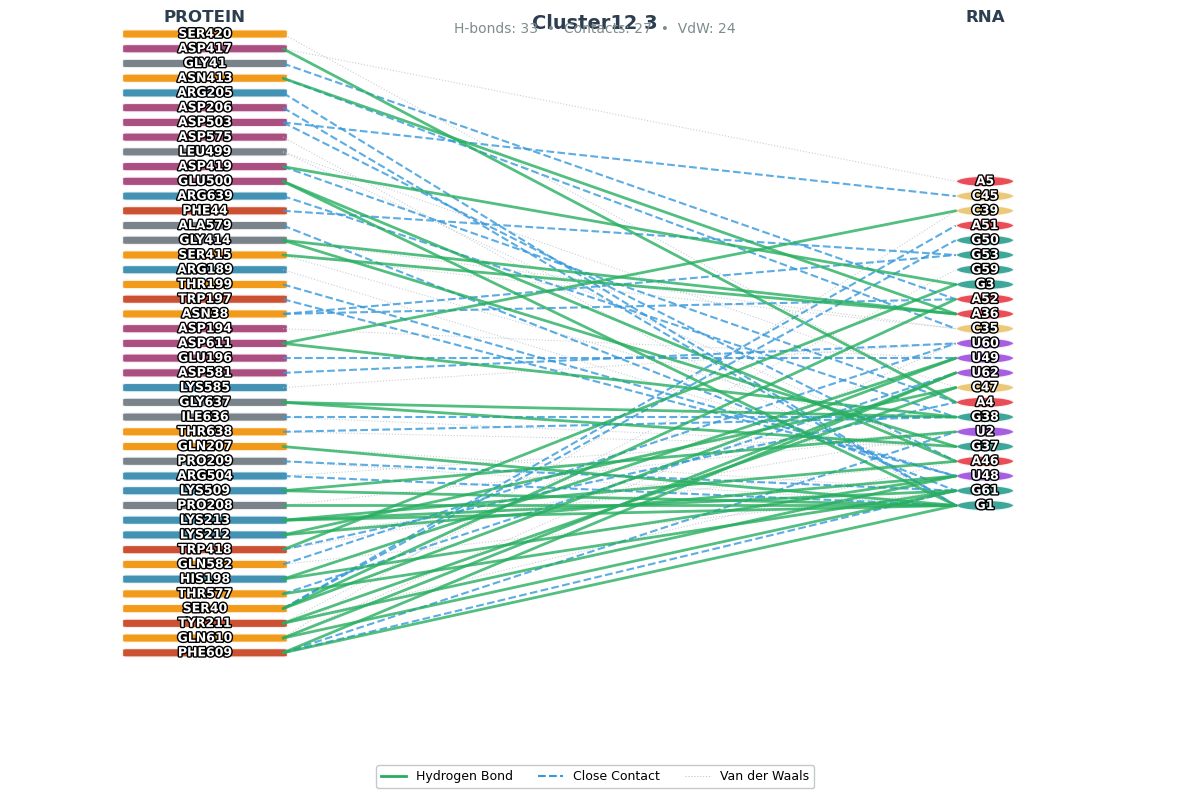

Saved: publication_diagram_hbonds_cluster5_3.png


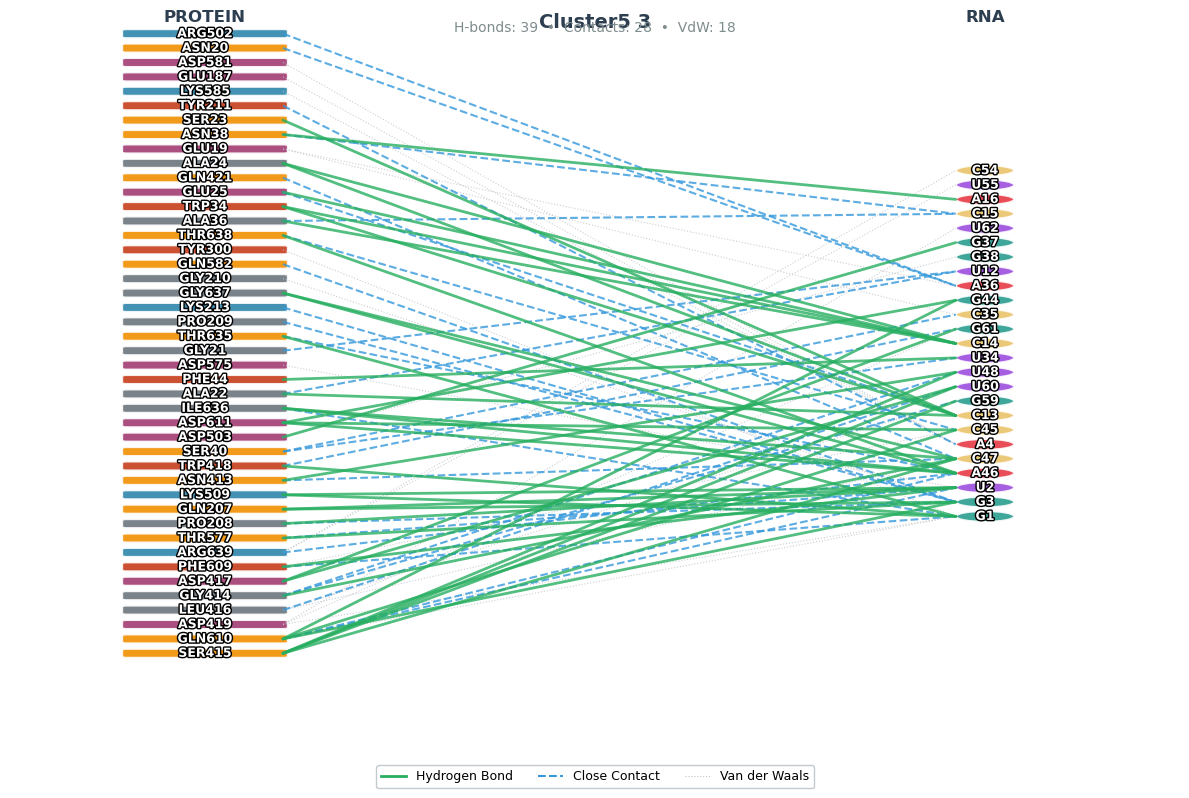

Created publication-quality diagrams with improved distance labeling


In [16]:
# Create publication-quality interaction diagrams
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle
import numpy as np
from matplotlib import patheffects

def create_publication_quality_diagram(pdb_file, analysis_result, show_distances='auto', max_distance_labels=20):
    """
    Create a publication-quality 2D interaction diagram.
    Works with both DNA and RNA.
    
    Parameters:
    - show_distances: 'auto', 'all', 'none', or 'hbonds_only'
    - max_distance_labels: maximum number of distance labels to show
    """
    
    if not analysis_result['residue_interactions']:
        return None
    
    # Create figure with publication settings
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.linewidth': 0.5,
        'lines.linewidth': 1.0
    })
    
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    interactions = analysis_result['residue_interactions']
    
    # Detect nucleic acid type
    nucleic_type = analysis_result.get('nucleic_type', 'DNA')
    nucleic_label = nucleic_type if nucleic_type in ['DNA', 'RNA'] else 'Nucleic Acid'
    
    # Get unique residues
    protein_residues = set()
    nucleic_residues = set()
    
    for interaction in interactions:
        protein_residues.add(interaction['protein_residue'])
        nucleic_residues.add(interaction['nucleic_residue'])
    
    protein_residues = sorted(list(protein_residues))
    nucleic_residues = sorted(list(nucleic_residues))
    
    # Calculate smart positioning to minimize line crossings
    n_prot = len(protein_residues)
    n_nucleic = len(nucleic_residues)
    
    # Create interaction matrix for smart positioning
    interaction_matrix = np.zeros((n_prot, n_nucleic))
    for interaction in interactions:
        try:
            p_idx = protein_residues.index(interaction['protein_residue'])
            n_idx = nucleic_residues.index(interaction['nucleic_residue'])
            interaction_matrix[p_idx, n_idx] = 1
        except:
            continue
    
    # Optimize residue order to minimize crossings
    def optimize_order(residues, matrix, is_protein=True):
        if len(residues) <= 1:
            return residues
        
        # Simple optimization: sort by interaction pattern
        if is_protein:
            scores = [(i, np.sum(matrix[i, :] * np.arange(matrix.shape[1]))) 
                     for i in range(len(residues))]
        else:
            scores = [(i, np.sum(matrix[:, i] * np.arange(matrix.shape[0]))) 
                     for i in range(len(residues))]
        
        sorted_indices = [i for i, _ in sorted(scores, key=lambda x: x[1])]
        return [residues[i] for i in sorted_indices]
    
    protein_residues = optimize_order(protein_residues, interaction_matrix, True)
    nucleic_residues = optimize_order(nucleic_residues, interaction_matrix, False)
    
    # Professional color scheme
    prot_colors = {
        'positive': '#2E86AB',  # Professional blue
        'negative': '#A23B72',  # Professional magenta
        'polar': '#F18F01',     # Professional orange
        'aromatic': '#C73E1D',  # Professional red
        'hydrophobic': '#6C757D', # Professional gray
        'special': '#495057'    # Dark gray
    }
    
    # Updated nucleic acid colors to include RNA bases
    nucleic_colors = {
        # DNA
        'A': '#E63946', 'DA': '#E63946',  # Professional red
        'T': '#457B9D', 'DT': '#457B9D',  # Professional blue
        'G': '#2A9D8F', 'DG': '#2A9D8F',  # Professional teal
        'C': '#E9C46A', 'DC': '#E9C46A',  # Professional yellow
        # RNA
        'U': '#9D4EDD', 'DU': '#9D4EDD', 'RU': '#9D4EDD',  # Professional purple for Uracil
        'RA': '#E63946', 'RG': '#2A9D8F', 'RC': '#E9C46A',  # RNA versions
        # Full names
        'ADE': '#E63946', 'THY': '#457B9D', 'GUA': '#2A9D8F', 
        'CYT': '#E9C46A', 'URA': '#9D4EDD'
    }
    
    def get_residue_color(res_type):
        if res_type in ['ARG', 'LYS', 'HIS']:
            return prot_colors['positive']
        elif res_type in ['ASP', 'GLU']:
            return prot_colors['negative']
        elif res_type in ['SER', 'THR', 'ASN', 'GLN']:
            return prot_colors['polar']
        elif res_type in ['PHE', 'TRP', 'TYR']:
            return prot_colors['aromatic']
        elif res_type in ['CYS', 'MET']:
            return prot_colors['special']
        else:
            return prot_colors['hydrophobic']
    
    # Calculate positions with better spacing for distance labels
    base_spacing = 1.2
    y_spacing = min(base_spacing, 8.0 / max(n_prot, n_nucleic))
    y_spacing = max(y_spacing, 0.8)
    
    protein_positions = {}
    nucleic_positions = {}
    
    # Center vertically with increased spacing
    prot_start_y = (n_prot - 1) * y_spacing / 2
    nucleic_start_y = (n_nucleic - 1) * y_spacing / 2
    
    for i, res in enumerate(protein_residues):
        protein_positions[res] = (-4.0, prot_start_y - i * y_spacing)
    
    for i, res in enumerate(nucleic_residues):
        nucleic_positions[res] = (4.0, nucleic_start_y - i * y_spacing)
    
    # Draw protein residues with better styling
    for res, (x, y) in protein_positions.items():
        res_type = res[:3]
        color = get_residue_color(res_type)
        
        # Clean rounded rectangle
        box = FancyBboxPatch((x-0.8, y-0.2), 1.6, 0.4,
                           boxstyle="round,pad=0.05",
                           facecolor=color, edgecolor='white',
                           linewidth=1.5, alpha=0.9)
        ax.add_patch(box)
        
        # High contrast text with outline
        text = ax.text(x, y, res, ha='center', va='center',
                      fontsize=9, fontweight='bold', color='white')
        text.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
    
    # Draw nucleic acid residues
    for res, (x, y) in nucleic_positions.items():
        # Handle different naming conventions
        if res.startswith('D'):
            base_type = res[:2]  # DA, DT, DG, DC, DU
        elif res.startswith('R'):
            base_type = res[:2]  # RA, RG, RC, RU
        else:
            base_type = res[:1]  # A, T, G, C, U
        
        color = nucleic_colors.get(base_type, '#6C757D')
        
        # Clean circle
        circle = Circle((x, y), 0.3, facecolor=color, edgecolor='white',
                       linewidth=1.5, alpha=0.9)
        ax.add_patch(circle)
        
        # High contrast text
        text = ax.text(x, y, res, ha='center', va='center',
                      fontsize=9, fontweight='bold', color='white')
        text.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
    
    # Draw interactions with professional styling
    interaction_counts = {'H-bond': 0, 'Contact': 0, 'VdW': 0}
    
    # Group interactions by type for cleaner drawing
    hbonds = []
    contacts = []
    vdw = []
    
    for interaction in interactions:
        distance = interaction['min_distance']
        if distance < 3.5:
            hbonds.append(interaction)
            interaction_counts['H-bond'] += 1
        elif distance < 4.5:
            contacts.append(interaction)
            interaction_counts['Contact'] += 1
        else:
            vdw.append(interaction)
            interaction_counts['VdW'] += 1
    
    # Determine which interactions should show distance labels
    def should_show_distance(int_type, int_list):
        if show_distances == 'none':
            return False
        elif show_distances == 'all':
            return len(int_list) <= max_distance_labels
        elif show_distances == 'hbonds_only':
            return int_type == 'H-bond' and len(int_list) <= max_distance_labels
        else:  # 'auto'
            if int_type == 'H-bond':
                return len(int_list) <= max_distance_labels
            elif int_type == 'Contact':
                return len(int_list) <= max(5, max_distance_labels // 3)
            else:
                return False
    
    # Draw interactions in order: VdW (background), contacts, H-bonds (foreground)
    interaction_styles = [
        (vdw, '#BDC3C7', 0.8, ':', 'VdW'),
        (contacts, '#3498DB', 1.5, '--', 'Contact'),
        (hbonds, '#27AE60', 2.0, '-', 'H-bond')
    ]
    
    distance_label_count = 0
    
    for int_list, color, width, style, name in interaction_styles:
        show_dist_for_type = should_show_distance(name, int_list)
        
        for interaction in int_list:
            prot_res = interaction['protein_residue']
            nucleic_res = interaction['nucleic_residue']
            distance = interaction['min_distance']
            
            if prot_res in protein_positions and nucleic_res in nucleic_positions:
                x1, y1 = protein_positions[prot_res]
                x2, y2 = nucleic_positions[nucleic_res]
                
                # Draw clean line
                line_start_x = x1 + 0.8
                line_end_x = x2 - 0.3
                ax.plot([line_start_x, line_end_x], [y1, y2],
                       color=color, linewidth=width, linestyle=style,
                       alpha=0.8, solid_capstyle='round')
                
                # Add distance label
                if show_dist_for_type and distance_label_count < max_distance_labels:
                    mid_x = (line_start_x + line_end_x) / 2
                    mid_y = (y1 + y2) / 2
                    
                    offset_y = 0.15 if (distance_label_count % 2 == 0) else -0.15
                    label_y = mid_y + offset_y
                    
                    ax.text(mid_x, label_y, f'{distance:.1f}',
                           ha='center', va='center', fontsize=8,
                           bbox=dict(boxstyle="round,pad=0.25",
                                   facecolor='white', edgecolor=color,
                                   alpha=0.95, linewidth=0.8),
                           color=color, fontweight='bold',
                           zorder=10)
                    distance_label_count += 1
    
    # Set clean limits
    ax.set_xlim(-6.0, 6.0)
    y_range = max(abs(prot_start_y), abs(nucleic_start_y)) + 1.2
    ax.set_ylim(-y_range, y_range)
    
    # Professional title and labels - use detected nucleic acid type
    ax.text(-4.0, y_range - 0.3, 'PROTEIN', ha='center', va='center',
           fontsize=12, fontweight='bold', color='#2C3E50')
    ax.text(4.0, y_range - 0.3, nucleic_label.upper(), ha='center', va='center',
           fontsize=12, fontweight='bold', color='#2C3E50')
    
    # Clean title
    title = pdb_file.replace('.pdb', '').replace('_', ' ').title()
    ax.text(0, y_range - 0.6, title, ha='center', va='center',
           fontsize=14, fontweight='bold', color='#2C3E50')
    
    # Interaction summary
    summary = f"H-bonds: {interaction_counts['H-bond']}  •  " + \
              f"Contacts: {interaction_counts['Contact']}  •  " + \
              f"VdW: {interaction_counts['VdW']}"
    ax.text(0, y_range - 0.9, summary, ha='center', va='center',
           fontsize=10, color='#7F8C8D')
    
    # Professional legend
    legend_elements = [
        plt.Line2D([0], [0], color='#27AE60', linewidth=2, label='Hydrogen Bond'),
        plt.Line2D([0], [0], color='#3498DB', linewidth=1.5, linestyle='--', label='Close Contact'),
        plt.Line2D([0], [0], color='#BDC3C7', linewidth=0.8, linestyle=':', label='Van der Waals')
    ]
    
    legend = ax.legend(handles=legend_elements, loc='lower center',
                      bbox_to_anchor=(0.5, -0.18), ncol=3,
                      frameon=True, fancybox=True, shadow=False,
                      edgecolor='#BDC3C7', fontsize=9)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # Remove axes
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    return fig

# Create publication-quality diagrams with better distance label control
if analysis_df is not None:
    print("Creating publication-quality interaction diagrams...")
    print("Works with both DNA and RNA structures")
    
    top_poses = analysis_df.nlargest(3, 'total_interactions')
    
    # Different options for distance labels
    distance_options = [
        ('auto', 15),
        ('hbonds_only', 20),
        ('all', 10)
    ]
    
    for i, (idx, row) in enumerate(top_poses.iterrows()):
        nucleic_info = f" ({row['nucleic_type']})" if 'nucleic_type' in row else ""
        print(f"Creating publication diagram {i+1}/3: {row['file']}{nucleic_info}")
        
        # Use different distance label strategies
        show_dist, max_labels = distance_options[i % len(distance_options)]
        
        fig = create_publication_quality_diagram(
            row['file'], row, 
            show_distances=show_dist, 
            max_distance_labels=max_labels
        )
        
        if fig:
            filename = f"publication_diagram_{row['file'].replace('.pdb', '')}.png"
            pdf_filename = f"publication_diagram_{row['file'].replace('.pdb', '')}.pdf"
            
            # Save in high quality
            fig.savefig(filename, dpi=300, bbox_inches='tight',
                       facecolor='white', edgecolor='none', 
                       pad_inches=0.2)
            fig.savefig(pdf_filename, dpi=300, bbox_inches='tight',
                       facecolor='white', edgecolor='none', 
                       pad_inches=0.2)
            
            print(f"Saved: {filename} and {pdf_filename}")
            plt.show()
    
    # Create a version with consistent distance labeling for all plots
    print("\nCreating consistent diagrams (H-bonds only)...")
    for i, (idx, row) in enumerate(top_poses.iterrows()):
        fig = create_publication_quality_diagram(
            row['file'], row, 
            show_distances='hbonds_only',
            max_distance_labels=25
        )
        
        if fig:
            filename = f"publication_diagram_hbonds_{row['file'].replace('.pdb', '')}.png"
            fig.savefig(filename, dpi=300, bbox_inches='tight',
                       facecolor='white', edgecolor='none', 
                       pad_inches=0.2)
            print(f"Saved: {filename}")
            plt.show()
    
    print("Created publication-quality diagrams with improved distance labeling")
else:
    print("No data available")

In [17]:
# 3D Molecular View (best pose)
if fp_count is not None and pose_molecules and 'analysis_df' in locals():
    best_pose_idx = analysis_df['total_interactions'].idxmax()
    
    print(f"Creating 3D view for best pose ({best_pose_idx})...")
    
    view = fp_count.plot_3d(
        pose_molecules[best_pose_idx], 
        protein_mol, 
        frame=best_pose_idx,
        display_all=False
    )
    
    print("3D Controls: Mouse=rotate, Scroll=zoom, Hover=details")
    view.show()
else:
    print("Cannot create 3D view - missing data")

NameError: name 'fp_count' is not defined

In [ ]:
# Advanced structural analysis for drug design insights
def structural_druggability_analysis():
    """Analyze structural features for drug design."""
    
    if analysis_df is None:
        return
    
    print("=== STRUCTURAL DRUGGABILITY ANALYSIS ===")
    
    # Analyze binding site characteristics
    def analyze_binding_interface():
        """Analyze protein-DNA binding interface characteristics."""
        
        interface_analysis = []
        
        for _, row in analysis_df.iterrows():
            if row['residue_interactions']:
                # Analyze interface composition
                protein_residues = set()
                dna_residues = set()
                
                for interaction in row['residue_interactions']:
                    protein_residues.add(interaction['protein_residue'][:3])
                    dna_residues.add(interaction['dna_residue'])
                
                # Categorize protein residues
                hydrophobic = sum(1 for res in protein_residues 
                                if res in ['ALA', 'VAL', 'LEU', 'ILE', 'PRO', 'PHE', 'MET'])
                polar = sum(1 for res in protein_residues 
                          if res in ['SER', 'THR', 'ASN', 'GLN', 'TYR'])
                charged = sum(1 for res in protein_residues 
                            if res in ['ARG', 'LYS', 'HIS', 'ASP', 'GLU'])
                aromatic = sum(1 for res in protein_residues 
                             if res in ['PHE', 'TRP', 'TYR', 'HIS'])
                
                interface_analysis.append({
                    'file': row['file'],
                    'cluster': row['cluster'],
                    'interface_size': len(protein_residues),
                    'hydrophobic_fraction': hydrophobic / len(protein_residues),
                    'polar_fraction': polar / len(protein_residues),
                    'charged_fraction': charged / len(protein_residues),
                    'aromatic_fraction': aromatic / len(protein_residues),
                    'dna_diversity': len(dna_residues)
                })
        
        return pd.DataFrame(interface_analysis)
    
    interface_df = analyze_binding_interface()
    
    if not interface_df.empty:
        print("Interface Composition Analysis:")
        print(f"Mean interface size: {interface_df['interface_size'].mean():.1f} residues")
        print(f"Hydrophobic content: {interface_df['hydrophobic_fraction'].mean():.2f} ± {interface_df['hydrophobic_fraction'].std():.2f}")
        print(f"Polar content: {interface_df['polar_fraction'].mean():.2f} ± {interface_df['polar_fraction'].std():.2f}")
        print(f"Charged content: {interface_df['charged_fraction'].mean():.2f} ± {interface_df['charged_fraction'].std():.2f}")
        
        # Druggability prediction
        def predict_druggability(row):
            """Predict druggability based on interface characteristics."""
            score = 0
            
            # Favorable characteristics for small molecule binding
            if 0.3 <= row['hydrophobic_fraction'] <= 0.6:  # Optimal hydrophobic content
                score += 2
            if row['aromatic_fraction'] > 0.2:  # Aromatic residues for pi-stacking
                score += 1
            if row['interface_size'] >= 8:  # Sufficient binding site size
                score += 1
            if 0.2 <= row['polar_fraction'] <= 0.4:  # Balanced polarity
                score += 1
            
            return score
        
        interface_df['druggability_score'] = interface_df.apply(predict_druggability, axis=1)
        
        print(f"\nDruggability Scores (0-5 scale):")
        print(f"Mean: {interface_df['druggability_score'].mean():.2f}")
        print(f"Best poses (score ≥ 3): {(interface_df['druggability_score'] >= 3).sum()}")
        
        # Visualization
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Interface composition by cluster
        composition_cols = ['hydrophobic_fraction', 'polar_fraction', 'charged_fraction', 'aromatic_fraction']
        cluster_composition = interface_df.groupby('cluster')[composition_cols].mean()
        
        cluster_composition.plot(kind='bar', stacked=True, ax=axes[0,0])
        axes[0,0].set_title('Interface Composition by Cluster')
        axes[0,0].set_ylabel('Fraction')
        axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Druggability scores
        sns.boxplot(data=interface_df, x='cluster', y='druggability_score', ax=axes[0,1])
        axes[0,1].set_title('Druggability Score by Cluster')
        axes[0,1].set_ylabel('Druggability Score')
        
        # Interface size vs binding score
        if 'binding_score' in analysis_df.columns:
            merged_df = interface_df.merge(analysis_df[['file', 'binding_score']], on='file')
            axes[1,0].scatter(merged_df['interface_size'], merged_df['binding_score'], 
                            c=merged_df['cluster'], cmap='viridis', alpha=0.7)
            axes[1,0].set_xlabel('Interface Size (residues)')
            axes[1,0].set_ylabel('Binding Score')
            axes[1,0].set_title('Interface Size vs Binding Affinity')
        
        # Composition radar chart for best cluster
        best_cluster = interface_df.groupby('cluster')['druggability_score'].mean().idxmax()
        best_cluster_data = cluster_composition.loc[best_cluster]
        
        angles = np.linspace(0, 2*np.pi, len(composition_cols), endpoint=False)
        angles = np.concatenate((angles, [angles[0]]))
        values = np.concatenate((best_cluster_data.values, [best_cluster_data.values[0]]))
        
        ax_radar = plt.subplot(224, projection='polar')
        ax_radar.plot(angles, values, 'o-', linewidth=2)
        ax_radar.fill(angles, values, alpha=0.25)
        ax_radar.set_thetagrids(angles[:-1] * 180/np.pi, 
                               ['Hydrophobic', 'Polar', 'Charged', 'Aromatic'])
        ax_radar.set_title(f'Best Cluster {best_cluster} Interface Profile')
        
        plt.tight_layout()
        plt.show()
        
        return interface_df
    
    return None

# Run structural analysis
structural_results = structural_druggability_analysis()